# Digit classifier comparison for OpenMANIPULATOR-X

**Experiment:** compare a small scratch CNN, ImageNet-pretrained MobileNetV3-Small, and ImageNet-pretrained ResNet18 on the existing `DIGIT_CLASSIFICATION_V1` crops. The dataset is not regenerated. No shape model or robot motion is used.

1. Attach the prepared dataset as a Kaggle Dataset. A folder containing `dataset_manifest.json` or a ZIP containing `DIGIT_CLASSIFICATION_V1` is supported.
2. Enable a GPU. Enable Internet for the official torchvision weights, or ensure those weights are already cached.
3. Run once with `SMOKE_TEST=True` to check the pipeline. This uses 10% of **train only** and does not evaluate test.
4. Set `SMOKE_TEST=False`, restart the session, and run top to bottom for the complete experiment. Three full models on 325,090 training crops may take more than one Kaggle session. For separate sessions, set `MODELS_TO_RUN` to one model and `RUN_FINAL_EVALUATION=False`; save that run's output as a Kaggle Dataset. In a final session attach the three output datasets, set `MODELS_TO_RUN=[]`, populate `EXTERNAL_CHECKPOINT_ROOTS`, and set `RUN_FINAL_EVALUATION=True`.

The earlier dataset build did not finish its exhaustive image-read validation. This notebook performs a bounded preflight and exposes suspect crops. Source-specific evaluation is essential: only **27** Printed Digit crops are in the current test split.


In [1]:
import os, io, json, math, random, time, copy, shutil, zipfile, warnings
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, ImageOps, ImageEnhance
from IPython.display import display
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support,
                             classification_report, confusion_matrix)
from sklearn.model_selection import train_test_split
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from torchvision.models import MobileNet_V3_Small_Weights, ResNet18_Weights

SEED = 42
INPUT_SIZE = 128                 # 96, 128, or 160 may be tested in a later experiment
BATCH_SIZE = 128                 # lower to 64 or 32 if CUDA reports out of memory
NUM_WORKERS = min(4, os.cpu_count() or 1)
SMOKE_TEST = False               # set False for the final full-data run
MODELS_TO_RUN = ["CNN_FROM_SCRATCH", "MOBILENETV3_SMALL", "RESNET18"]
RUN_FINAL_EVALUATION = True      # False for a single-model training session
EXTERNAL_CHECKPOINT_ROOTS = []   # Path('/kaggle/input/prior-run/digit_model_experiments'), etc.
MAX_EPOCHS_CNN = 30
MAX_EPOCHS_PRETRAINED = 20      # includes the head-only stage
HEAD_EPOCHS = 3
EARLY_STOPPING_PATIENCE = 5
USE_CLASS_WEIGHTS = True
RUN_PRINTED_ADAPTATION = False  # reserved; not part of this fair comparison
EVALUATE_TEST = (not SMOKE_TEST) and RUN_FINAL_EVALUATION
PREFLIGHT_SCAN_LIMIT = 2000
DATASET_ROOT_OVERRIDE = '/kaggle/input/datasets/aymenslimani/number-degit-dataset'
DATASET_ZIP_OVERRIDE = None     # e.g. Path('/kaggle/input/my-dataset/DIGIT_CLASSIFICATION_V1.zip')
OUTPUT_ROOT = Path('/kaggle/working/digit_model_experiments') if Path('/kaggle/working').exists() else Path('digit_model_experiments_output')
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.benchmark = True
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('torch', torch.__version__, 'torchvision', __import__('torchvision').__version__, 'device', device)
if device.type != 'cuda':
    warnings.warn('GPU is unavailable. Full training will be very slow; enable a Kaggle GPU.')


torch 2.10.0+cu128 torchvision 0.25.0+cu128 device cuda


## 1. Locate the prepared dataset and audit its splits

The manifest, report, class table, and metadata are read from the attached dataset. The test split is never resplit or used for model selection. A folder count and a random image-read sample form the lightweight preflight; the earlier exhaustive validation gap remains documented.


In [2]:
def find_dataset():
    if DATASET_ROOT_OVERRIDE is not None:
        root = Path(DATASET_ROOT_OVERRIDE)
        if not (root / 'dataset_manifest.json').is_file():
            raise FileNotFoundError(root / 'dataset_manifest.json')
        return root
    search_roots = [Path('/kaggle/input'), Path.cwd(), Path.cwd().parent]
    for base in search_roots:
        if base.exists():
            hits = sorted(base.rglob('dataset_manifest.json'))
            hits = [p for p in hits if p.parent.name == 'DIGIT_CLASSIFICATION_V1']
            if hits:
                return hits[0].parent
    zip_candidates = [Path(DATASET_ZIP_OVERRIDE)] if DATASET_ZIP_OVERRIDE else []
    if not zip_candidates and Path('/kaggle/input').exists():
        zip_candidates = sorted(Path('/kaggle/input').rglob('*.zip'))
    for archive_path in zip_candidates:
        with zipfile.ZipFile(archive_path) as archive:
            names = archive.namelist()
            if not any('DIGIT_CLASSIFICATION_V1/dataset_manifest.json' in n for n in names):
                continue
            destination = OUTPUT_ROOT / 'dataset_unpacked'
            destination.mkdir(exist_ok=True)
            base = destination.resolve()
            for member in archive.infolist():
                target = (destination / member.filename).resolve()
                if target != base and base not in target.parents:
                    raise ValueError('Unsafe ZIP member path: ' + member.filename)
            archive.extractall(destination)
            hits = list(destination.rglob('dataset_manifest.json'))
            hits = [p for p in hits if p.parent.name == 'DIGIT_CLASSIFICATION_V1']
            if hits:
                return hits[0].parent
    raise FileNotFoundError('Attach DIGIT_CLASSIFICATION_V1 as a Kaggle Dataset or set DATASET_ROOT_OVERRIDE / DATASET_ZIP_OVERRIDE.')

DATA_ROOT = find_dataset()
manifest = json.loads((DATA_ROOT / 'dataset_manifest.json').read_text(encoding='utf-8'))
source_report = (DATA_ROOT / 'dataset_report.md').read_text(encoding='utf-8')
class_table = pd.read_csv(DATA_ROOT / 'class_distribution.csv')
metadata = pd.read_csv(DATA_ROOT / 'metadata.csv', dtype={'source_image': str, 'crop_file': str})
metadata['digit'] = metadata['digit'].astype(int)
metadata['crop_file'] = metadata['crop_file'].str.replace('\\', '/', regex=False)
metadata['source_dataset'] = metadata['source_dataset'].astype(str)
print('Dataset:', DATA_ROOT)
print('Manifest validation status:', manifest.get('full_validation_status', 'not recorded'))
print('Report excerpt:', source_report[-700:])
display(class_table)


Dataset: /kaggle/input/datasets/aymenslimani/number-degit-dataset
Manifest validation status: skipped at user request; final image-by-image scan incomplete
Report excerpt: s not performed. Training has not started.

## Validation status and visual review

The complete image-by-image validation pass was stopped at the user's request because it was taking too long. The dataset is **not fully validated**. Build-time checks rejected invalid or tiny boxes, and each saved crop was encoded by Pillow, but the final all-file readability and folder reconciliation did not finish.

Visual review of the galleries found several Printed Digit crops with strokes cut off at image edges and some SVHN crops that include part of a neighboring digit. These examples need human review before model training; the current automatic filters do not detect all such semantic crop defects.



,Digit,SVHN Train,SVHN Extra,Printed Train,Val,Test,Total
0,0,4391,22338,29,505,1740,29003
1,1,11218,43791,23,1210,4855,61097
2,2,9299,36898,33,1061,4138,51429
3,3,7535,30030,31,813,2879,41288
4,4,6585,24730,32,745,2518,34610
5,5,6165,26339,33,639,2381,35557
6,6,5164,20454,40,512,1977,28147
7,7,4928,21776,35,545,2016,29300
8,8,4509,17448,42,484,1660,24143
9,9,4159,17002,33,436,1589,23219


In [3]:
expected_splits = {'train', 'val', 'test'}
expected_classes = {str(i) for i in range(10)}
assert set(metadata['unified_split']) == expected_splits
assert set(metadata['digit']) == set(range(10))
assert not metadata['crop_file'].duplicated().any(), 'Duplicate metadata crop paths'
assert metadata['crop_file'].str.split('/').str[0].isin(expected_splits).all()
assert (metadata['crop_file'].str.split('/').str[1].astype(int) == metadata['digit']).all()

folder_counts = {}
split_filenames = {}
for split in ('train', 'val', 'test'):
    split_dir = DATA_ROOT / split
    assert split_dir.is_dir(), split_dir
    actual_classes = {p.name for p in split_dir.iterdir() if p.is_dir()}
    assert actual_classes == expected_classes, (split, actual_classes)
    names = set()
    for digit in range(10):
        folder = split_dir / str(digit)
        with os.scandir(folder) as entries:
            files = [entry.name for entry in entries if entry.is_file()]
        folder_counts[(split, digit)] = len(files)
        names.update(files)
    split_filenames[split] = names
assert not (split_filenames['train'] & split_filenames['val'])
assert not (split_filenames['train'] & split_filenames['test'])
assert not (split_filenames['val'] & split_filenames['test'])
metadata_counts = metadata.groupby(['unified_split', 'digit']).size().to_dict()
assert folder_counts == metadata_counts, 'Folder/metadata count mismatch'
assert len(metadata) == manifest['total_crops']
assert metadata['unified_split'].value_counts().to_dict() == manifest['split_counts']
assert metadata['source_dataset'].value_counts().to_dict() == manifest['source_counts']
group_splits = metadata.groupby(['source_dataset', 'source_split', 'source_image'])['unified_split'].nunique()
assert group_splits.max() == 1, 'Original source image crosses splits'

sample = metadata.sample(n=min(200, len(metadata)), random_state=SEED)
for rel in sample['crop_file']:
    with Image.open(DATA_ROOT / rel) as image:
        image.verify()
summary = metadata.groupby(['unified_split', 'source_dataset']).size().unstack(fill_value=0)
display(summary)
print('Lightweight preflight passed: all folder/metadata counts and 200 sampled images checked.')
print('This does not replace a full image-by-image readability scan.')


source_dataset,Printed,SVHN
unified_split,,
test,27,25726
train,331,324759
val,39,6911


Lightweight preflight passed: all folder/metadata counts and 200 sampled images checked.
This does not replace a full image-by-image readability scan.


### Suspect crop report and galleries

Geometry flags use all metadata rows. Contrast/blank flags use a reproducible bounded image sample. Flags are for review; no crop is deleted. The training gallery shows 100 random train crops, as requested.


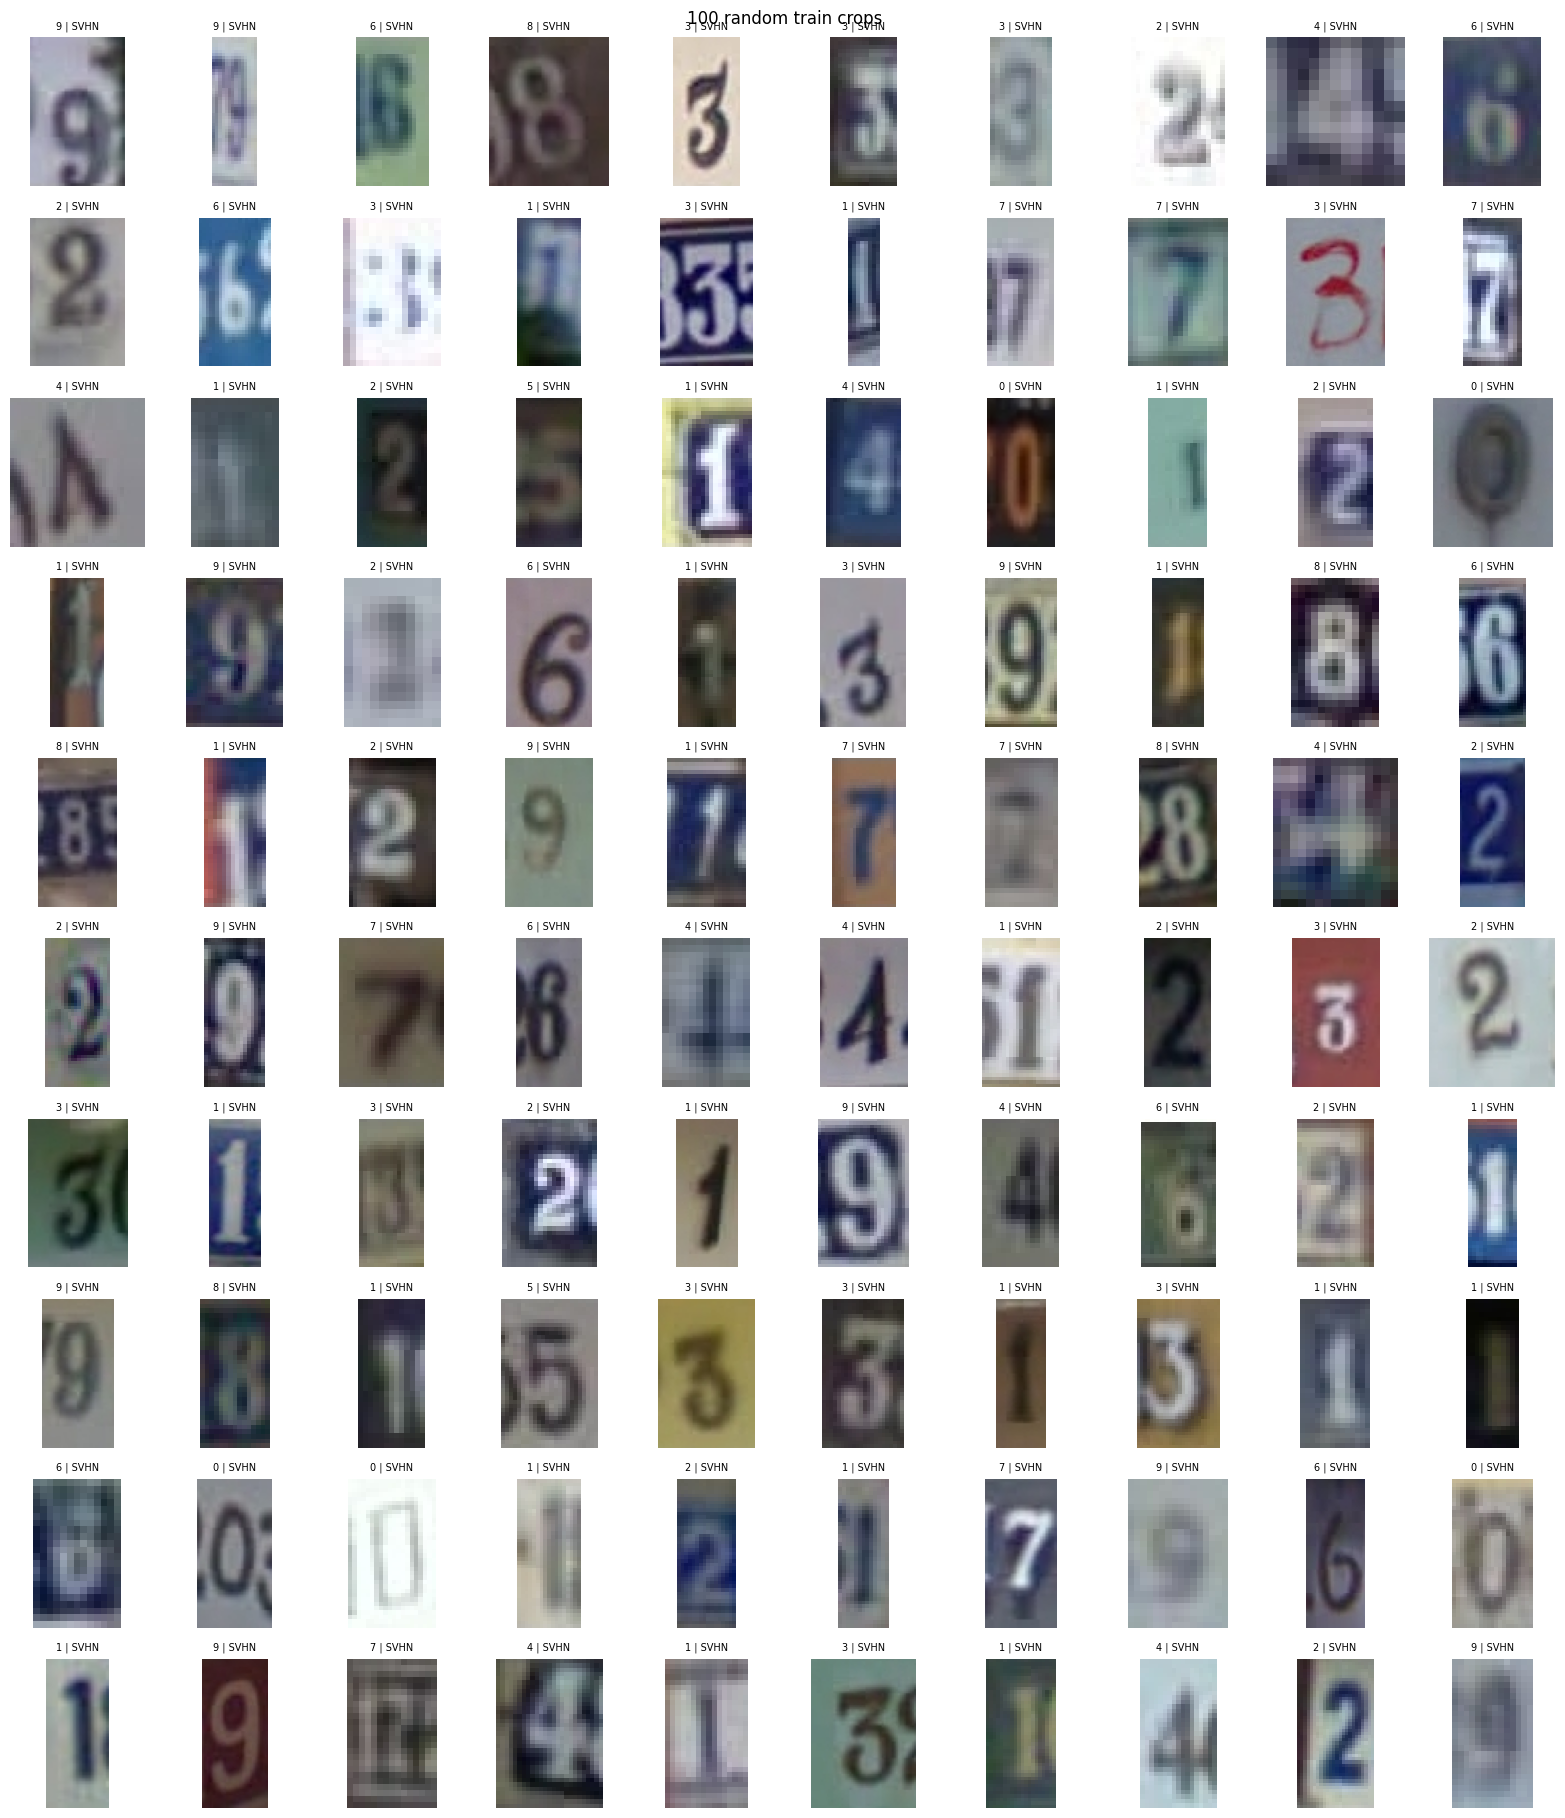

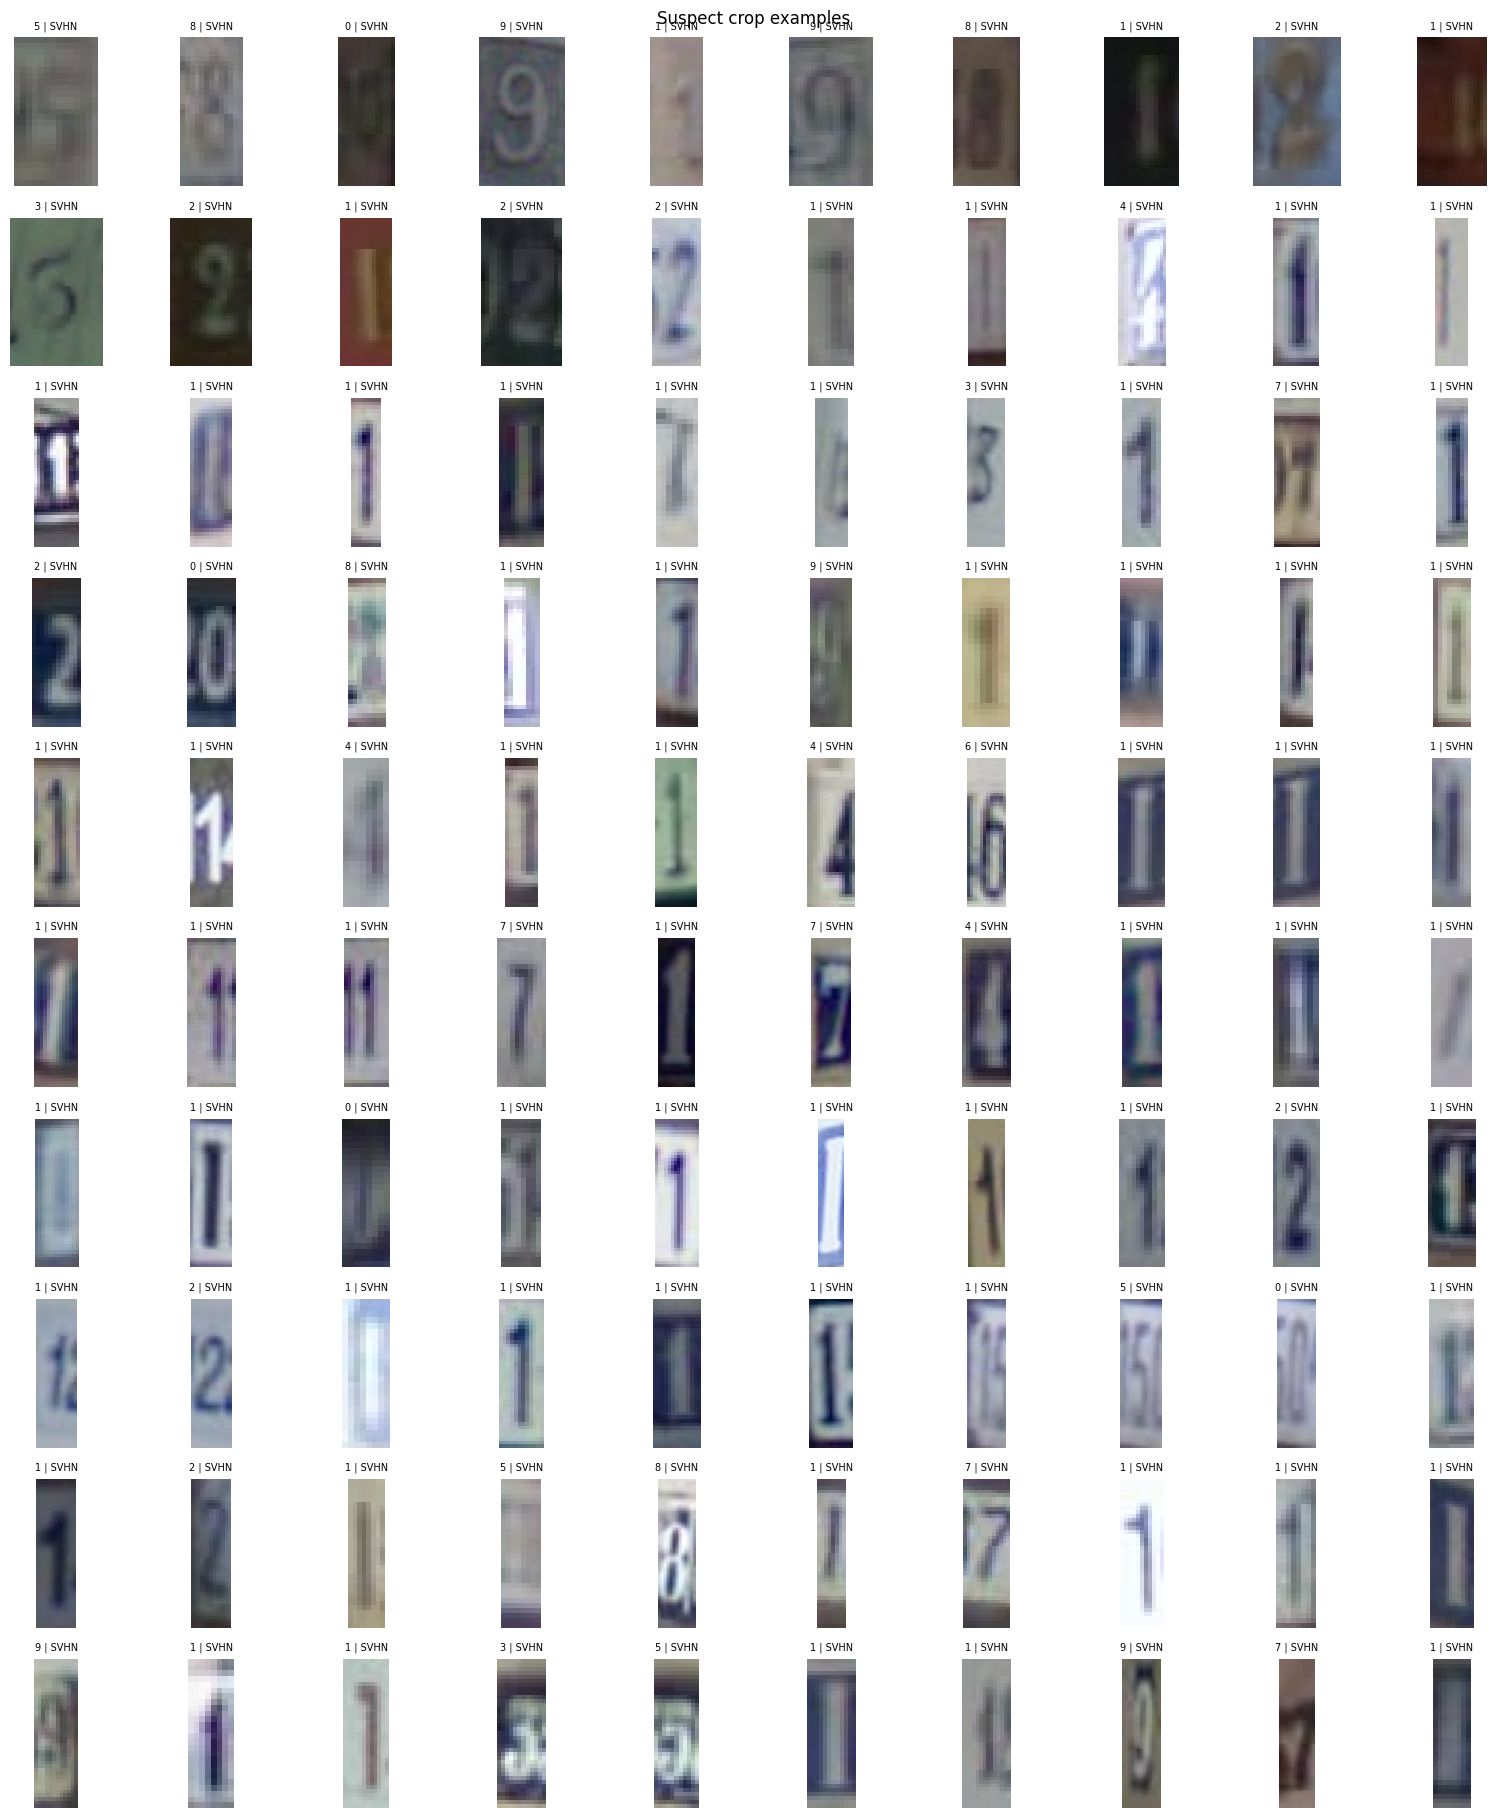

Suspect count: 88710 flags: {'flag_small': 83123, 'flag_aspect': 14259, 'flag_low_contrast': 14, 'flag_possible_blank': 0}


In [4]:
geometry = metadata[['crop_file', 'digit', 'source_dataset', 'unified_split', 'crop_width', 'crop_height']].copy()
geometry['crop_width'] = pd.to_numeric(geometry['crop_width'])
geometry['crop_height'] = pd.to_numeric(geometry['crop_height'])
ratio = geometry['crop_width'] / geometry['crop_height']
geometry['flag_small'] = (geometry[['crop_width', 'crop_height']].min(axis=1) < 16)
geometry['flag_aspect'] = (ratio < 0.33) | (ratio > 3.0)
scan = metadata.sample(n=min(PREFLIGHT_SCAN_LIMIT, len(metadata)), random_state=SEED)
appearance = {}
for rel in scan['crop_file']:
    with Image.open(DATA_ROOT / rel) as image:
        gray = np.asarray(image.convert('L').resize((32, 32)), dtype=np.float32)
    appearance[rel] = (float(gray.std()), float(np.percentile(gray, 95) - np.percentile(gray, 5)))
geometry['gray_std'] = geometry['crop_file'].map(lambda x: appearance.get(x, (np.nan, np.nan))[0])
geometry['gray_p95_p5'] = geometry['crop_file'].map(lambda x: appearance.get(x, (np.nan, np.nan))[1])
geometry['flag_low_contrast'] = geometry['gray_std'] < 12
geometry['flag_possible_blank'] = geometry['gray_p95_p5'] < 18
flag_columns = ['flag_small', 'flag_aspect', 'flag_low_contrast', 'flag_possible_blank']
suspects = geometry.loc[geometry[flag_columns].any(axis=1)].copy()
suspects['flags'] = suspects[flag_columns].apply(lambda row: ','.join(c for c in flag_columns if row[c]), axis=1)
suspects.to_csv(OUTPUT_ROOT / 'suspect_crops.csv', index=False)

def crop_gallery(frame, output_file, title, n=100):
    chosen = frame.head(n)
    columns = 10
    rows = max(1, math.ceil(len(chosen) / columns))
    fig, axes = plt.subplots(rows, columns, figsize=(16, 1.85 * rows))
    for ax in np.asarray(axes).reshape(-1):
        ax.axis('off')
    for ax, (_, row) in zip(np.asarray(axes).reshape(-1), chosen.iterrows()):
        with Image.open(DATA_ROOT / row['crop_file']) as image:
            ax.imshow(image.convert('RGB'))
        ax.set_title(f"{row['digit']} | {row['source_dataset']}", fontsize=7)
        ax.axis('off')
    fig.suptitle(title)
    fig.tight_layout()
    fig.savefig(output_file, dpi=120)
    plt.show()

train_random_100 = metadata.loc[metadata['unified_split'] == 'train'].sample(n=100, random_state=SEED)
crop_gallery(train_random_100, OUTPUT_ROOT / 'random_100_train_crops.png', '100 random train crops')
suspects_gallery = suspects.sort_values(['flag_possible_blank', 'flag_low_contrast', 'flag_aspect', 'flag_small'], ascending=False)
crop_gallery(suspects_gallery, OUTPUT_ROOT / 'suspect_crops_gallery.png', 'Suspect crop examples')
print('Suspect count:', len(suspects), 'flags:', suspects[flag_columns].sum().to_dict())


In [5]:
preflight_lines = [
    '# Dataset preflight report',
    f'Dataset: `{DATA_ROOT}`',
    f"Manifest full-validation status: {manifest.get('full_validation_status', 'not recorded')}",
    f'Metadata rows and folder crops: {len(metadata):,}',
    f"Split counts: {metadata['unified_split'].value_counts().to_dict()}",
    f"Source counts: {metadata['source_dataset'].value_counts().to_dict()}",
    f"Test source counts: {metadata.loc[metadata.unified_split == 'test', 'source_dataset'].value_counts().to_dict()}",
    f'Suspect rows (geometry complete; appearance sample {len(scan)}): {len(suspects)}',
    f'Suspect flags: {suspects[flag_columns].sum().to_dict()}',
    'No crops were removed. Filename overlap and source-image split overlap checks passed.',
    'A random 200-image readability check passed; this is not exhaustive validation.',
    'Printed test has a very small denominator, so its accuracy is directional only.',
    'Gallery review is required because source-edge truncation and neighboring SVHN digits can survive numeric checks.',
]
(OUTPUT_ROOT / 'dataset_preflight_report.md').write_text('\n\n'.join(preflight_lines) + '\n', encoding='utf-8')
print((OUTPUT_ROOT / 'dataset_preflight_report.md').read_text())


# Dataset preflight report

Dataset: `/kaggle/input/datasets/aymenslimani/number-degit-dataset`

Manifest full-validation status: skipped at user request; final image-by-image scan incomplete

Metadata rows and folder crops: 357,793

Split counts: {'train': 325090, 'test': 25753, 'val': 6950}

Source counts: {'SVHN': 357396, 'Printed': 397}

Test source counts: {'SVHN': 25726, 'Printed': 27}

Suspect rows (geometry complete; appearance sample 2000): 88710

Suspect flags: {'flag_small': 83123, 'flag_aspect': 14259, 'flag_low_contrast': 14, 'flag_possible_blank': 0}

No crops were removed. Filename overlap and source-image split overlap checks passed.

A random 200-image readability check passed; this is not exhaustive validation.

Printed test has a very small denominator, so its accuracy is directional only.

Gallery review is required because source-edge truncation and neighboring SVHN digits can survive numeric checks.



## 2. Input processing and loaders

Every image is converted to RGB, padded to a centered square with its median border color, then resized to 128×128. Moderate augmentation is applied only to train. There are no flips or 180° rotations. ImageNet normalization is used for both pretrained models; the scratch CNN uses fixed RGB mean/std of 0.5 for a transparent baseline.


Train-only class weights: {0: np.float64(1.066), 1: np.float64(0.743), 2: np.float64(0.811), 3: np.float64(0.899), 4: np.float64(0.985), 5: np.float64(0.967), 6: np.float64(1.089), 7: np.float64(1.066), 8: np.float64(1.176), 9: np.float64(1.198)}


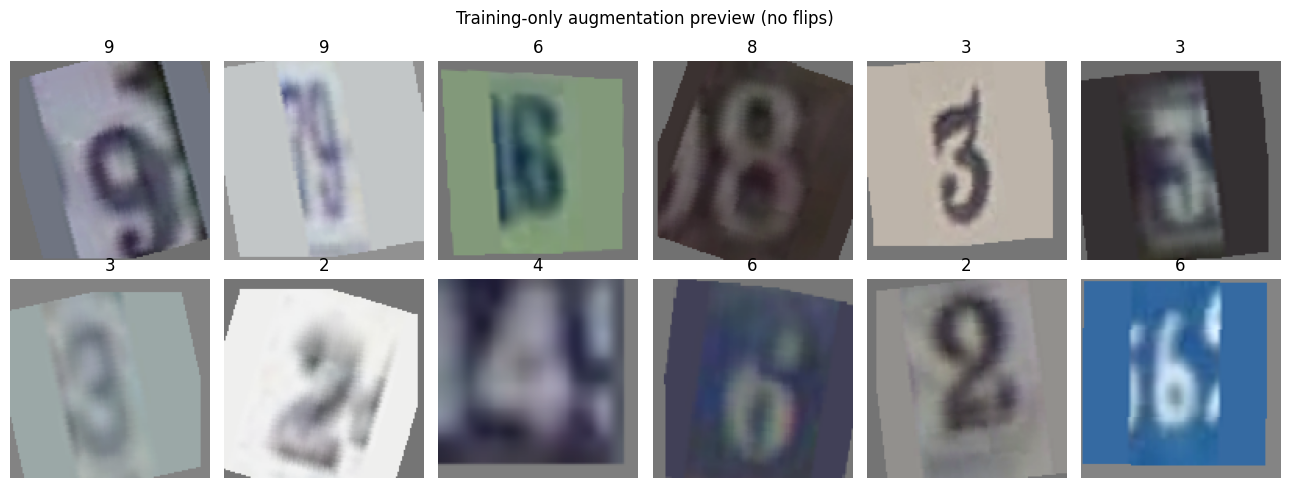

In [6]:
def pad_square(image):
    image = image.convert('RGB')
    array = np.asarray(image)
    border = np.concatenate([array[0], array[-1], array[:, 0], array[:, -1]], axis=0)
    fill = tuple(int(v) for v in np.median(border, axis=0))
    width, height = image.size
    side = max(width, height)
    left = (side - width) // 2
    top = (side - height) // 2
    canvas = Image.new('RGB', (side, side), fill)
    canvas.paste(image, (left, top))
    return canvas

augment = transforms.Compose([
    transforms.RandomRotation(20, fill=127),
    transforms.RandomPerspective(distortion_scale=0.15, p=0.20, fill=127),
    transforms.RandomAffine(degrees=0, translate=(0.06, 0.06), scale=(0.90, 1.10), fill=127),
    transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.10),
    transforms.RandomApply([transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 0.8))], p=0.10),
    transforms.RandomGrayscale(p=0.05),
])

def make_transform(train, pretrained):
    mean = (0.485, 0.456, 0.406) if pretrained else (0.5, 0.5, 0.5)
    std = (0.229, 0.224, 0.225) if pretrained else (0.5, 0.5, 0.5)
    steps = [transforms.Lambda(pad_square), transforms.Resize((INPUT_SIZE, INPUT_SIZE))]
    if train:
        steps.append(augment)
    steps.extend([transforms.ToTensor(), transforms.Normalize(mean, std)])
    return transforms.Compose(steps)

class DigitCrops(Dataset):
    def __init__(self, frame, transform):
        self.records = frame[['crop_file', 'digit', 'source_dataset']].to_records(index=False)
        self.transform = transform
    def __len__(self):
        return len(self.records)
    def __getitem__(self, index):
        rel, digit, source = self.records[index]
        with Image.open(DATA_ROOT / rel) as image:
            rgb = image.convert('RGB')
        return self.transform(rgb), int(digit), str(rel), str(source)

train_frame = metadata.loc[metadata.unified_split == 'train'].reset_index(drop=True)
val_frame = metadata.loc[metadata.unified_split == 'val'].reset_index(drop=True)
test_frame = metadata.loc[metadata.unified_split == 'test'].reset_index(drop=True)
if SMOKE_TEST:
    _, sample_indices = train_test_split(np.arange(len(train_frame)), test_size=0.10,
                                         stratify=train_frame['digit'], random_state=SEED)
    train_frame = train_frame.iloc[np.sort(sample_indices)].reset_index(drop=True)
    print('Smoke mode: stratified train subset', len(train_frame), 'validation unchanged', len(val_frame), 'test untouched')

full_train_counts = metadata.loc[metadata.unified_split == 'train', 'digit'].value_counts().reindex(range(10), fill_value=0)
weights = 1.0 / np.sqrt(full_train_counts.to_numpy(dtype=np.float64))
weights = weights / weights.mean()
class_weights = torch.tensor(weights, dtype=torch.float32, device=device) if USE_CLASS_WEIGHTS else None
print('Train-only class weights:', dict(zip(range(10), np.round(weights, 3))))

def loaders(pretrained):
    common = dict(batch_size=BATCH_SIZE, num_workers=NUM_WORKERS,
                  pin_memory=(device.type == 'cuda'), persistent_workers=(NUM_WORKERS > 0))
    return (
        DataLoader(DigitCrops(train_frame, make_transform(True, pretrained)), shuffle=True, **common),
        DataLoader(DigitCrops(val_frame, make_transform(False, pretrained)), shuffle=False, **common),
        DataLoader(DigitCrops(test_frame, make_transform(False, pretrained)), shuffle=False, **common),
    )

preview = train_frame.sample(n=12, random_state=SEED)
fig, axes = plt.subplots(2, 6, figsize=(13, 5))
for ax, (_, row) in zip(axes.flat, preview.iterrows()):
    with Image.open(DATA_ROOT / row.crop_file) as image:
        transformed = augment(pad_square(image).resize((INPUT_SIZE, INPUT_SIZE)))
    ax.imshow(transformed); ax.set_title(str(row.digit)); ax.axis('off')
fig.suptitle('Training-only augmentation preview (no flips)'); fig.tight_layout(); plt.show()


## 3. Define the three models

The scratch CNN uses 16→32→64→96 channels and global pooling so it remains genuinely small. Pretrained torchvision weights are mandatory for MobileNetV3-Small and ResNet18; a failed download stops the run instead of silently using random weights.


In [7]:
class CustomDigitCNN(nn.Module):
    def __init__(self, classes=10):
        super().__init__()
        def block(cin, cout, pool=True):
            layers = [nn.Conv2d(cin, cout, 3, padding=1, bias=False), nn.BatchNorm2d(cout), nn.ReLU(inplace=True),
                      nn.Conv2d(cout, cout, 3, padding=1, bias=False), nn.BatchNorm2d(cout), nn.ReLU(inplace=True)]
            return nn.Sequential(*layers, *([nn.MaxPool2d(2)] if pool else []))
        self.features = nn.Sequential(block(3, 16), block(16, 32), block(32, 64),
                                      nn.Conv2d(64, 96, 3, padding=1, bias=False), nn.BatchNorm2d(96),
                                      nn.ReLU(inplace=True), nn.AdaptiveAvgPool2d(1))
        self.classifier = nn.Sequential(nn.Flatten(), nn.Dropout(0.2), nn.Linear(96, classes))
    def forward(self, x):
        return self.classifier(self.features(x))

def create_model(name, load_imagenet_weights=True):
    if name == 'CNN_FROM_SCRATCH':
        return CustomDigitCNN(), False
    if name == 'MOBILENETV3_SMALL':
        model = models.mobilenet_v3_small(weights=MobileNet_V3_Small_Weights.DEFAULT if load_imagenet_weights else None)
        model.classifier[-1] = nn.Linear(model.classifier[-1].in_features, 10)
        return model, True
    if name == 'RESNET18':
        model = models.resnet18(weights=ResNet18_Weights.DEFAULT if load_imagenet_weights else None)
        model.fc = nn.Linear(model.fc.in_features, 10)
        return model, True
    raise ValueError(name)

def freeze_backbone(model, name, frozen):
    model._head_only = frozen
    for parameter in model.parameters():
        parameter.requires_grad = not frozen
    if frozen:
        head = model.fc if name == 'RESNET18' else model.classifier
        for parameter in head.parameters():
            parameter.requires_grad = True

scratch_probe = CustomDigitCNN()
print('Custom CNN parameters:', sum(p.numel() for p in scratch_probe.parameters()))
del scratch_probe


Custom CNN parameters: 128762


## 4. Train with validation-based checkpoint selection

AdamW uses inverse-square-root class weights from full train only. The scheduler is `ReduceLROnPlateau` on validation macro F1. Early stopping and `best.pt` use validation macro F1; test is not opened until **all selected models have finished training**. Mixed precision and gradient scaling activate on CUDA. Lower `BATCH_SIZE` if CUDA OOM occurs, then restart the run.


In [8]:
def classification_metrics(true, predicted):
    precision, recall, macro_f1, _ = precision_recall_fscore_support(
        true, predicted, labels=list(range(10)), average='macro', zero_division=0)
    _, _, weighted_f1, _ = precision_recall_fscore_support(
        true, predicted, labels=list(range(10)), average='weighted', zero_division=0)
    return {'accuracy': float(accuracy_score(true, predicted)), 'macro_precision': float(precision),
            'macro_recall': float(recall), 'macro_f1': float(macro_f1), 'weighted_f1': float(weighted_f1),
            'n': len(true)}

def run_epoch(model, loader, criterion, optimizer=None, scaler=None):
    training = optimizer is not None
    model.train(training)
    # Frozen backbone BatchNorm statistics stay fixed in the head-only stage.
    if training and getattr(model, '_head_only', False):
        for module in model.modules():
            if isinstance(module, nn.modules.batchnorm._BatchNorm):
                module.eval()
    true, predicted, losses = [], [], []
    context = torch.enable_grad() if training else torch.inference_mode()
    with context:
        for images, labels, _, _ in loader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            if training:
                optimizer.zero_grad(set_to_none=True)
            with torch.autocast(device_type=device.type, enabled=(device.type == 'cuda')):
                logits = model(images)
                loss = criterion(logits, labels)
            if training:
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()
            losses.append(float(loss.detach()) * len(labels))
            true.extend(labels.cpu().tolist())
            predicted.extend(logits.argmax(1).cpu().tolist())
    return {'loss': sum(losses) / len(true), **classification_metrics(true, predicted)}

def train_one(name):
    model, pretrained = create_model(name)
    model = model.to(device)
    train_loader, val_loader, _ = loaders(pretrained)
    criterion = nn.CrossEntropyLoss(weight=class_weights)
    scaler = torch.amp.GradScaler('cuda', enabled=(device.type == 'cuda'))
    output_dir = OUTPUT_ROOT / name.lower()
    (output_dir / 'metrics').mkdir(parents=True, exist_ok=True)
    (output_dir / 'plots').mkdir(exist_ok=True)
    best_f1, best_epoch, epoch_number = -1.0, -1, 0
    history = []
    stages = [('scratch', MAX_EPOCHS_CNN, 1e-3)] if not pretrained else [
        ('head', HEAD_EPOCHS, 1e-3), ('full', MAX_EPOCHS_PRETRAINED - HEAD_EPOCHS, 2e-4)]
    for stage, stage_epochs, learning_rate in stages:
        freeze_backbone(model, name, stage == 'head')
        optimizer = torch.optim.AdamW((p for p in model.parameters() if p.requires_grad),
                                      lr=learning_rate, weight_decay=1e-4)
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=2)
        patience = 0
        for _ in range(stage_epochs):
            epoch_number += 1
            train_result = run_epoch(model, train_loader, criterion, optimizer, scaler)
            val_result = run_epoch(model, val_loader, criterion)
            scheduler.step(val_result['macro_f1'])
            history.append({'epoch': epoch_number, 'stage': stage, 'lr': optimizer.param_groups[0]['lr'],
                            **{'train_' + k: v for k, v in train_result.items()},
                            **{'val_' + k: v for k, v in val_result.items()}})
            checkpoint = {'model_name': name, 'state_dict': model.state_dict(), 'epoch': epoch_number,
                          'input_size': INPUT_SIZE, 'smoke_test': SMOKE_TEST,
                          'validation_macro_f1': val_result['macro_f1']}
            torch.save(checkpoint, output_dir / 'last.pt')
            if val_result['macro_f1'] > best_f1:
                best_f1, best_epoch, patience = val_result['macro_f1'], epoch_number, 0
                torch.save(checkpoint, output_dir / 'best.pt')
            else:
                patience += 1
            print(name, stage, epoch_number, 'train loss', round(train_result['loss'], 4),
                  'val macro F1', round(val_result['macro_f1'], 4), flush=True)
            pd.DataFrame(history).to_csv(output_dir / 'metrics' / 'history.csv', index=False)
            if patience >= EARLY_STOPPING_PATIENCE and stage != 'head':
                print('Early stopping:', name, stage)
                break
    best = torch.load(output_dir / 'best.pt', map_location='cpu', weights_only=False)
    model.load_state_dict(best['state_dict'])
    val_result = run_epoch(model, val_loader, criterion)
    del train_loader, val_loader
    if device.type == 'cuda':
        torch.cuda.empty_cache()
    return {'model': model, 'pretrained': pretrained, 'best_epoch': best_epoch,
            'validation': val_result, 'output_dir': output_dir}

trained = {}
for model_name in MODELS_TO_RUN:
    trained[model_name] = train_one(model_name)
print('All selected models trained. Best checkpoints used validation macro F1 only.')


CNN_FROM_SCRATCH scratch 1 train loss 0.9385 val macro F1 0.7
CNN_FROM_SCRATCH scratch 2 train loss 0.3231 val macro F1 0.8516
CNN_FROM_SCRATCH scratch 3 train loss 0.2499 val macro F1 0.873
CNN_FROM_SCRATCH scratch 4 train loss 0.216 val macro F1 0.8924
CNN_FROM_SCRATCH scratch 5 train loss 0.195 val macro F1 0.8855
CNN_FROM_SCRATCH scratch 6 train loss 0.18 val macro F1 0.9131
CNN_FROM_SCRATCH scratch 7 train loss 0.1697 val macro F1 0.9068
CNN_FROM_SCRATCH scratch 8 train loss 0.1606 val macro F1 0.9151
CNN_FROM_SCRATCH scratch 9 train loss 0.1534 val macro F1 0.9166
CNN_FROM_SCRATCH scratch 10 train loss 0.1483 val macro F1 0.9287
CNN_FROM_SCRATCH scratch 11 train loss 0.143 val macro F1 0.9267
CNN_FROM_SCRATCH scratch 12 train loss 0.1392 val macro F1 0.9269
CNN_FROM_SCRATCH scratch 13 train loss 0.1346 val macro F1 0.9257
CNN_FROM_SCRATCH scratch 14 train loss 0.1196 val macro F1 0.9317
CNN_FROM_SCRATCH scratch 15 train loss 0.1162 val macro F1 0.9323
CNN_FROM_SCRATCH scratch 16 

100%|██████████| 9.83M/9.83M [00:00<00:00, 178MB/s]


MOBILENETV3_SMALL head 1 train loss 0.8751 val macro F1 0.6982
MOBILENETV3_SMALL head 2 train loss 0.7355 val macro F1 0.7178
MOBILENETV3_SMALL head 3 train loss 0.6969 val macro F1 0.7227
MOBILENETV3_SMALL full 4 train loss 0.3166 val macro F1 0.9127
MOBILENETV3_SMALL full 5 train loss 0.1305 val macro F1 0.9317
MOBILENETV3_SMALL full 6 train loss 0.1028 val macro F1 0.9337
MOBILENETV3_SMALL full 7 train loss 0.0882 val macro F1 0.9415
MOBILENETV3_SMALL full 8 train loss 0.0793 val macro F1 0.946
MOBILENETV3_SMALL full 9 train loss 0.072 val macro F1 0.9482
MOBILENETV3_SMALL full 10 train loss 0.0672 val macro F1 0.9484
MOBILENETV3_SMALL full 11 train loss 0.0621 val macro F1 0.9515
MOBILENETV3_SMALL full 12 train loss 0.0574 val macro F1 0.9451
MOBILENETV3_SMALL full 13 train loss 0.0541 val macro F1 0.9534
MOBILENETV3_SMALL full 14 train loss 0.0509 val macro F1 0.9523
MOBILENETV3_SMALL full 15 train loss 0.0486 val macro F1 0.9515
MOBILENETV3_SMALL full 16 train loss 0.0452 val mac

100%|██████████| 44.7M/44.7M [00:00<00:00, 212MB/s]


RESNET18 head 1 train loss 1.2217 val macro F1 0.5259
RESNET18 head 2 train loss 1.1104 val macro F1 0.5465
RESNET18 head 3 train loss 1.0944 val macro F1 0.5483
RESNET18 full 4 train loss 0.1671 val macro F1 0.9393
RESNET18 full 5 train loss 0.093 val macro F1 0.947
RESNET18 full 6 train loss 0.0816 val macro F1 0.954
RESNET18 full 7 train loss 0.0724 val macro F1 0.9518
RESNET18 full 8 train loss 0.0665 val macro F1 0.9558
RESNET18 full 9 train loss 0.0611 val macro F1 0.9562
RESNET18 full 10 train loss 0.0565 val macro F1 0.9588
RESNET18 full 11 train loss 0.0529 val macro F1 0.9555
RESNET18 full 12 train loss 0.0495 val macro F1 0.9576
RESNET18 full 13 train loss 0.0464 val macro F1 0.9591
RESNET18 full 14 train loss 0.0437 val macro F1 0.9575
RESNET18 full 15 train loss 0.0409 val macro F1 0.9614
RESNET18 full 16 train loss 0.039 val macro F1 0.9581
RESNET18 full 17 train loss 0.0367 val macro F1 0.9606
RESNET18 full 18 train loss 0.0346 val macro F1 0.9605
RESNET18 full 19 train 

## 5. Test evaluation and source-specific metrics

This section runs only when `SMOKE_TEST=False`. It is deliberately below the training loop. Overall, SVHN, and Printed results are reported with sample counts. With 27 Printed test crops, small accuracy changes are not reliable evidence of general robot-camera performance.


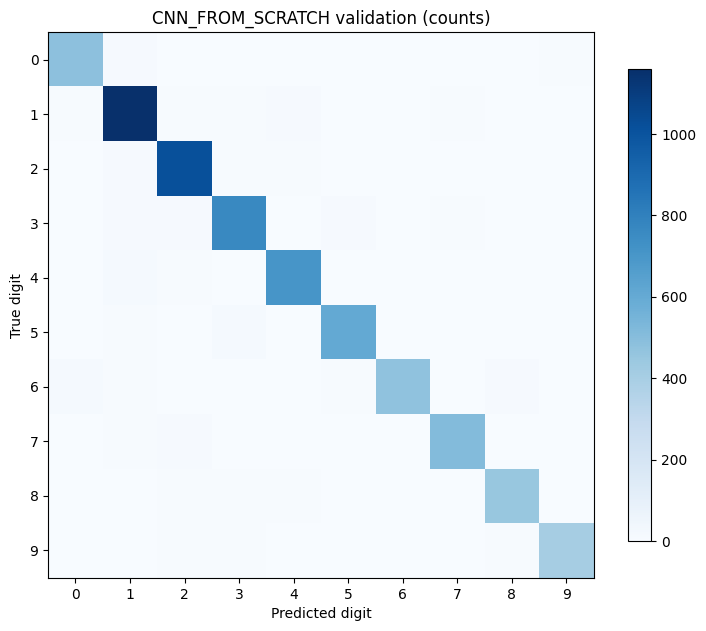

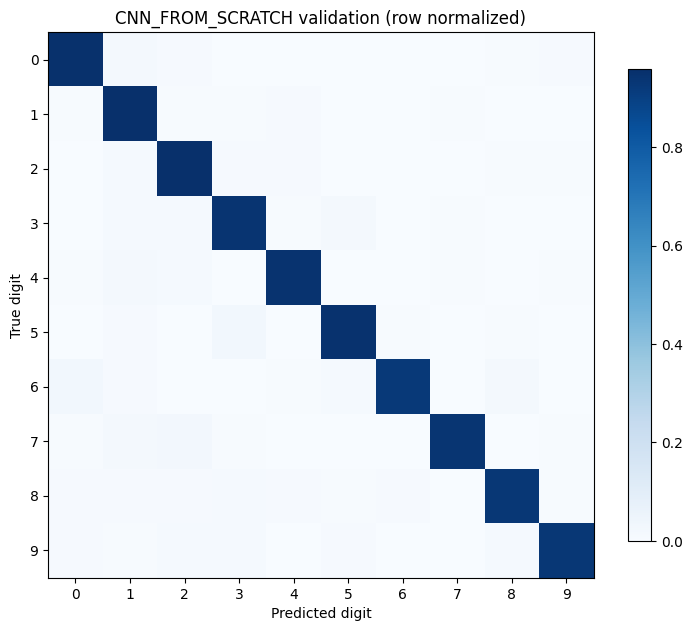

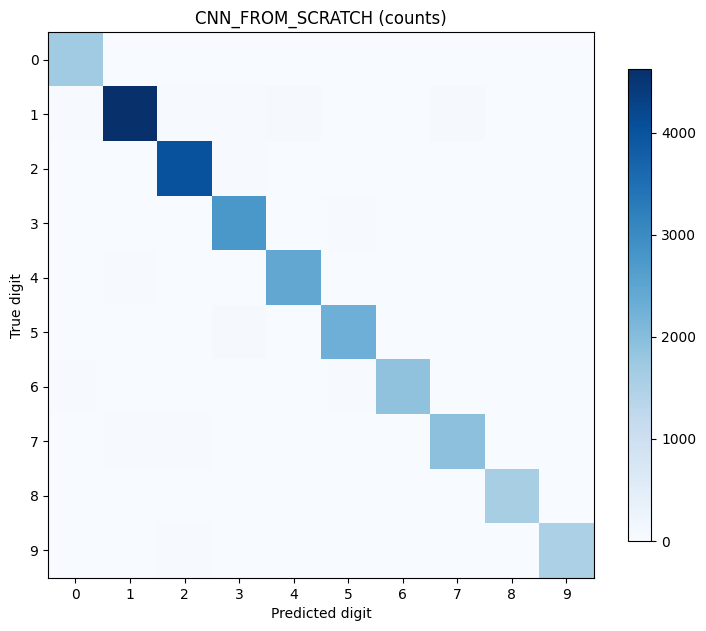

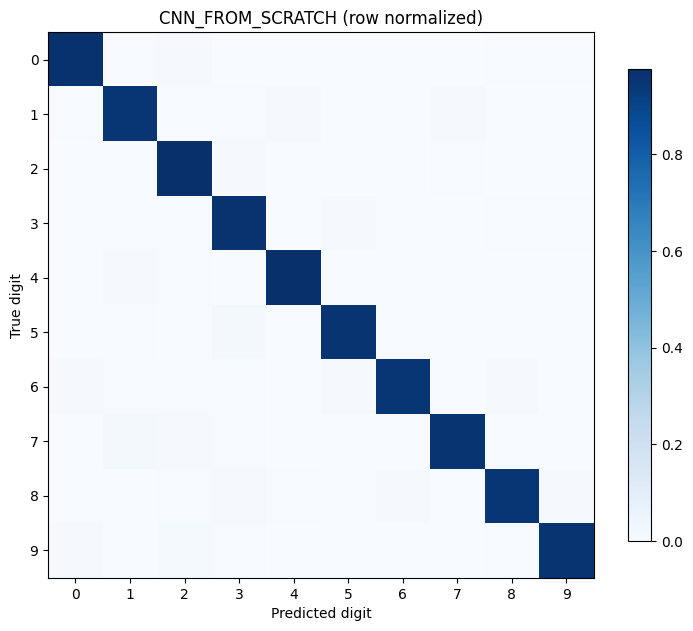

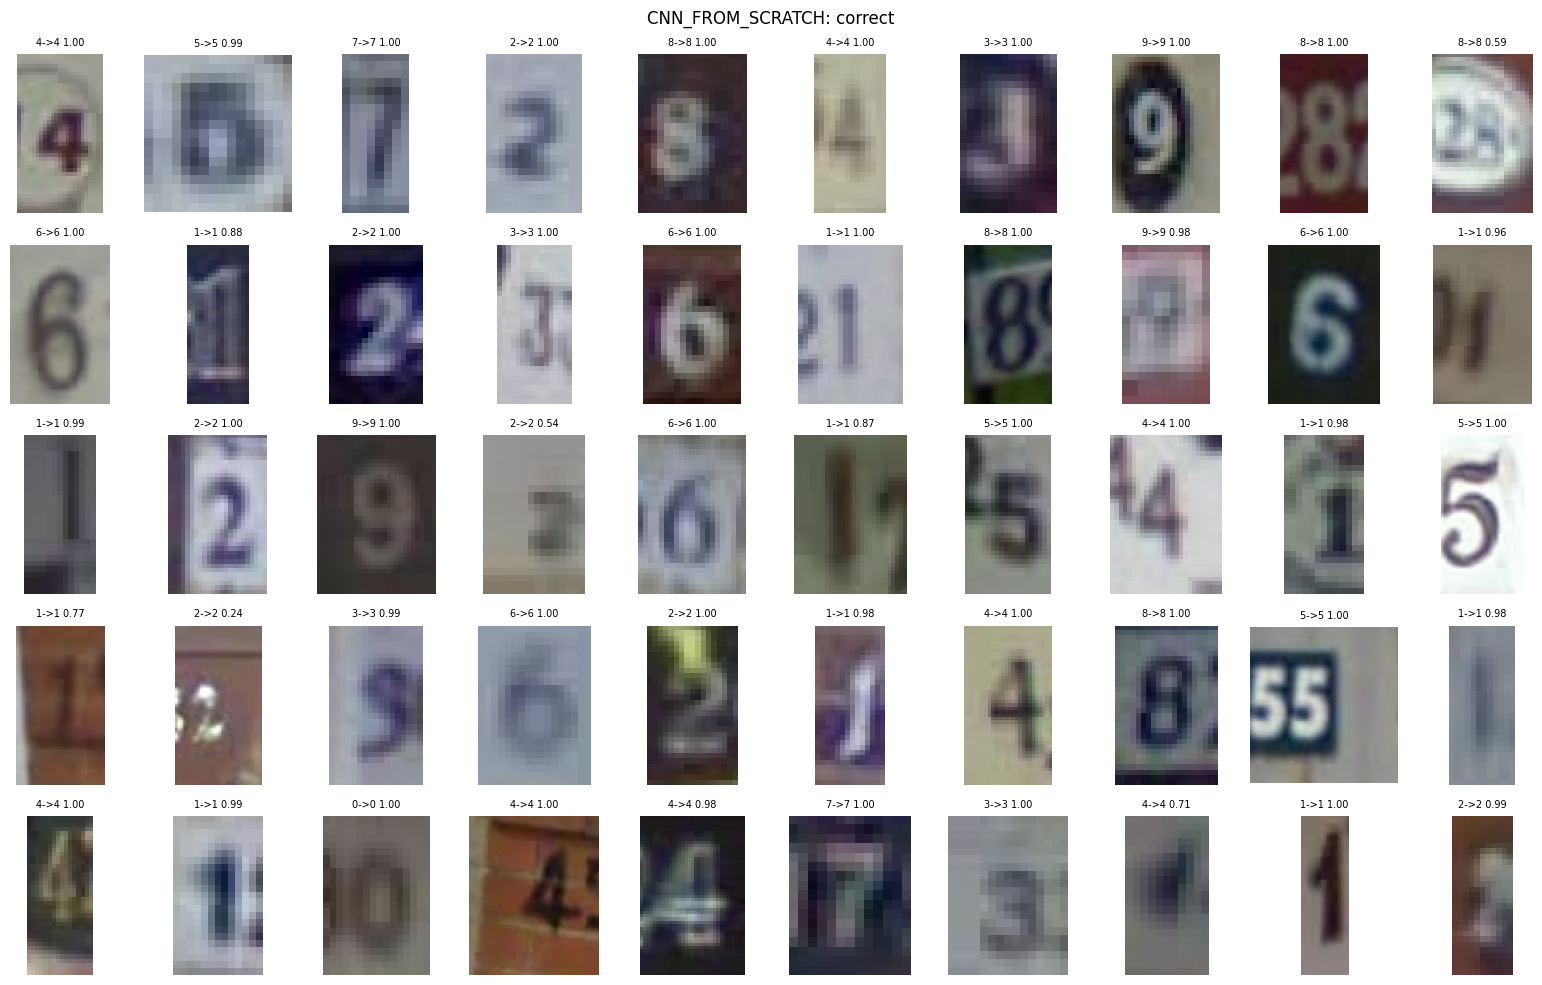

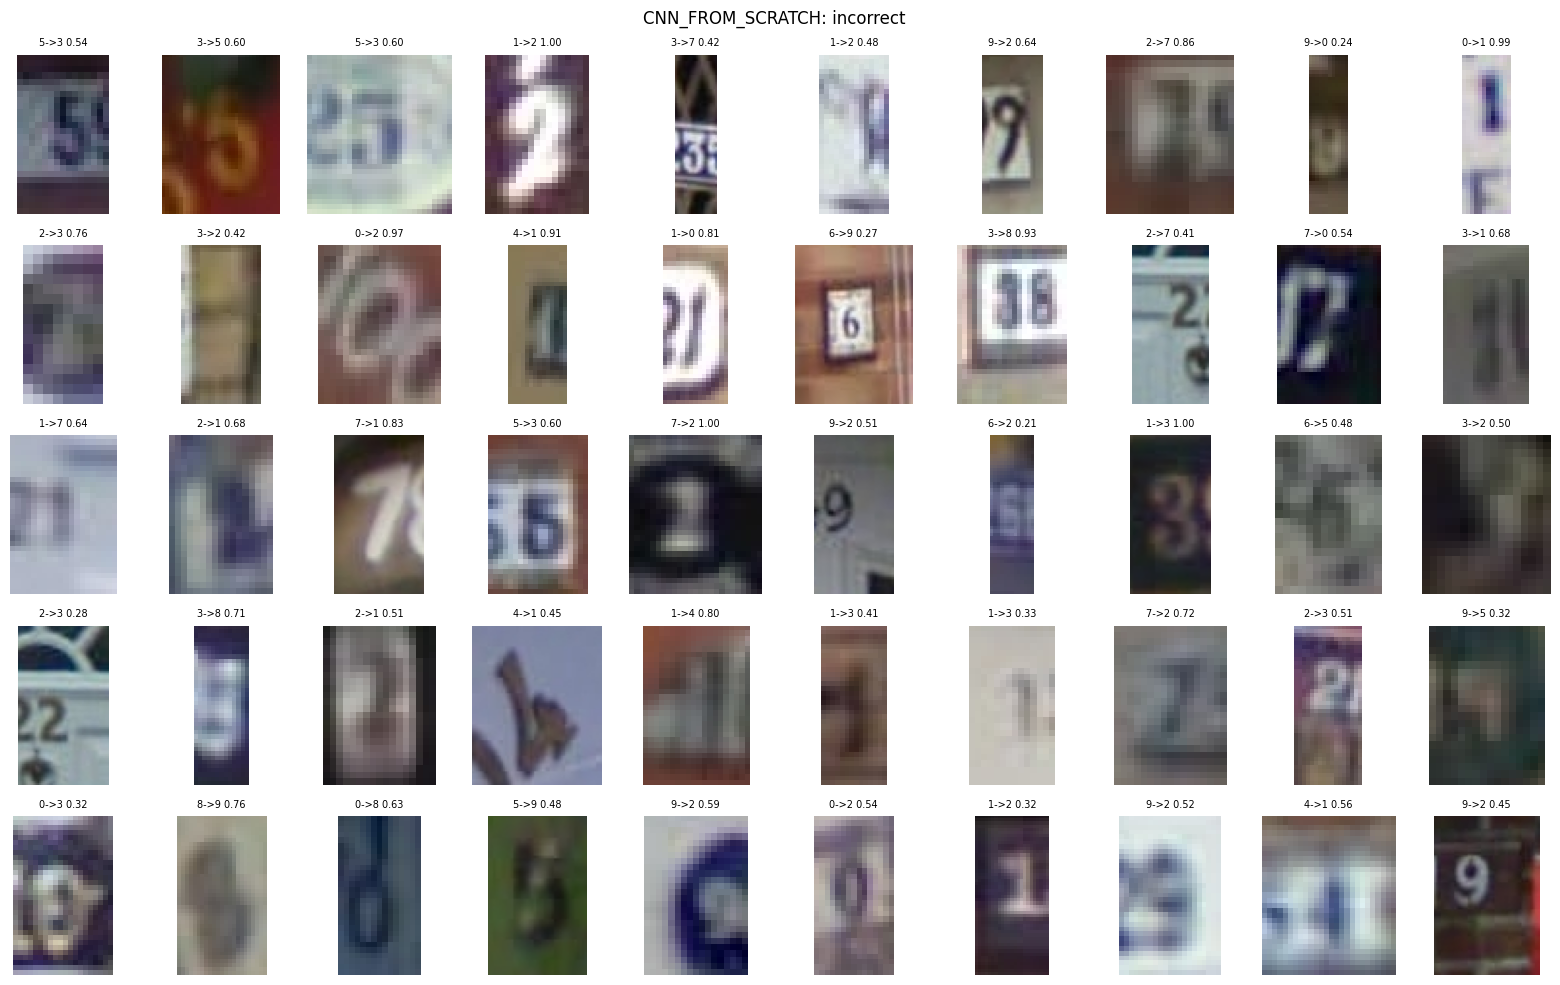

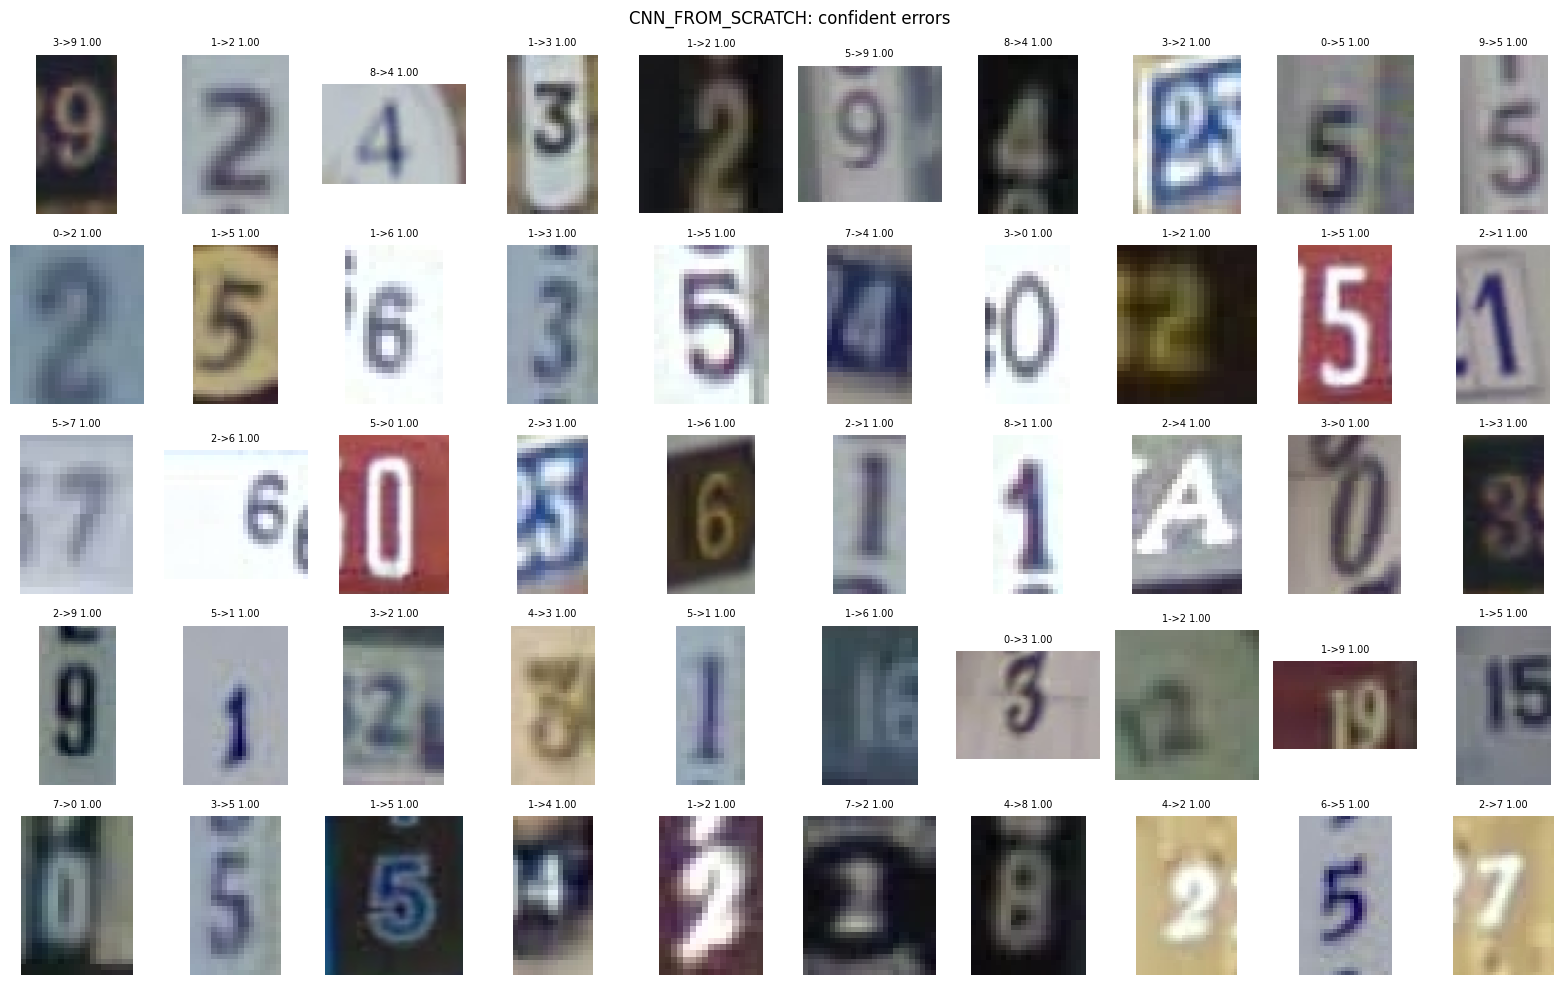

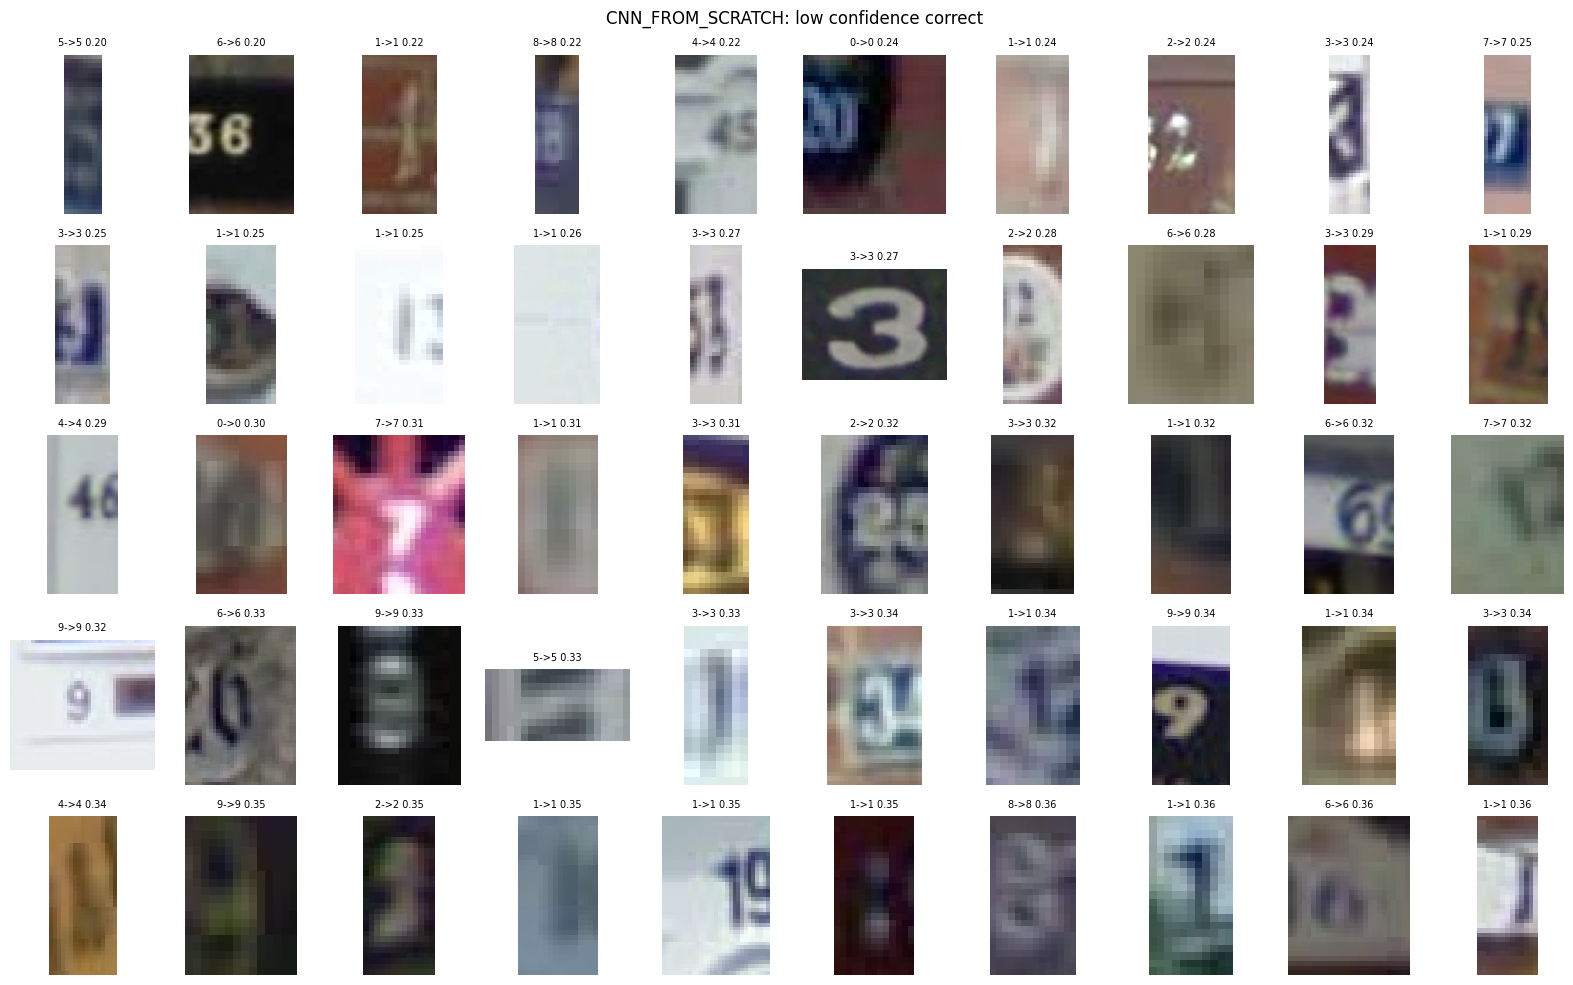

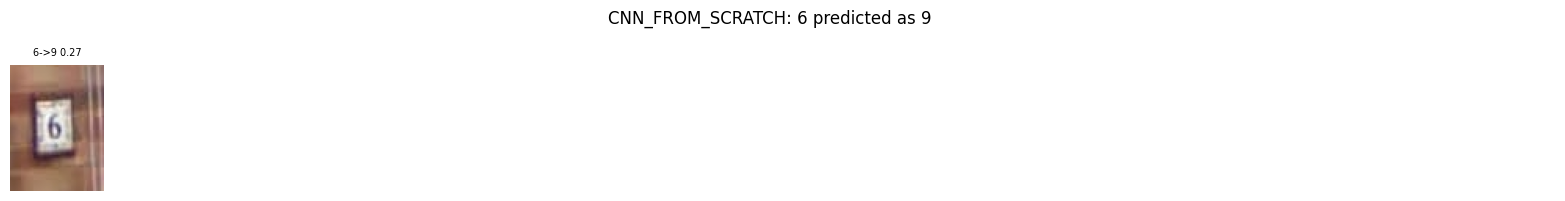

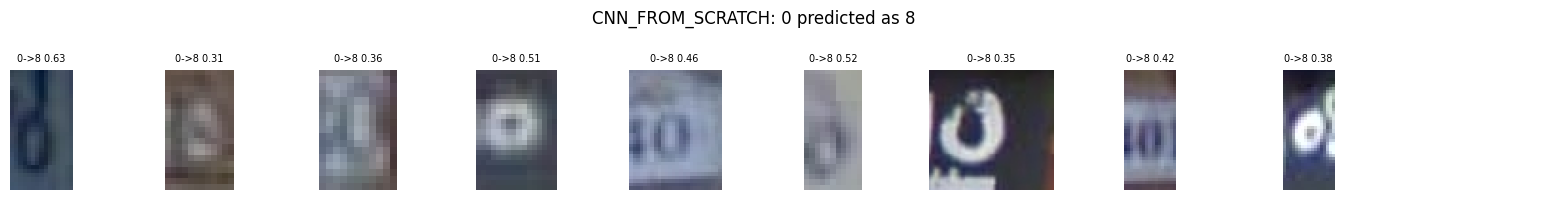

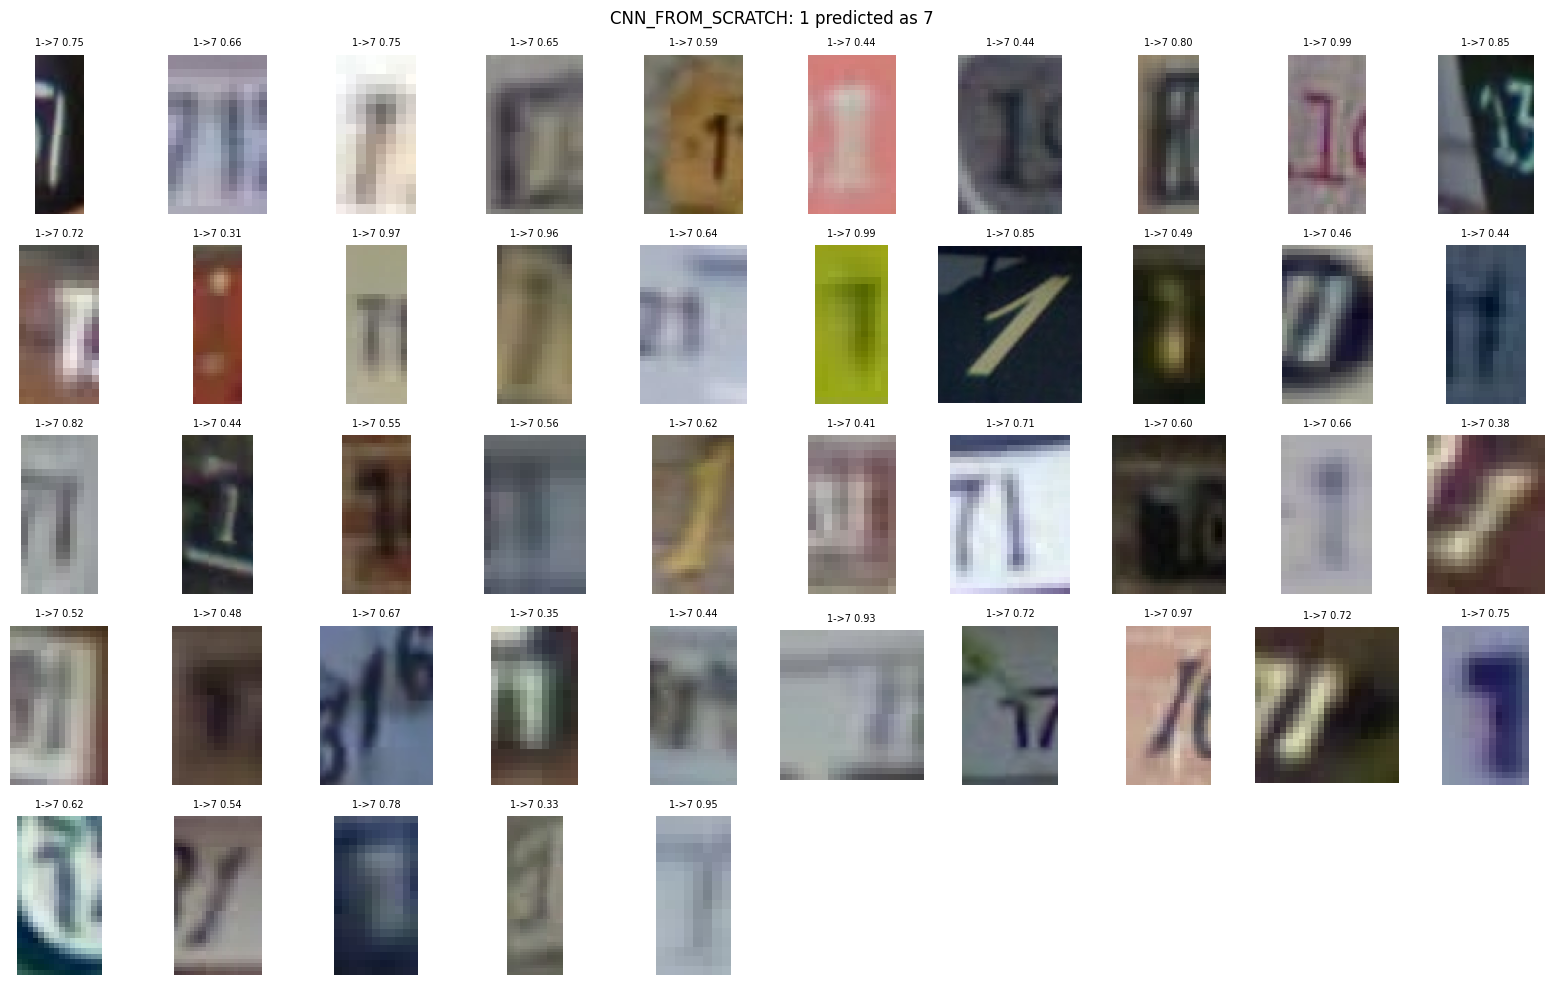

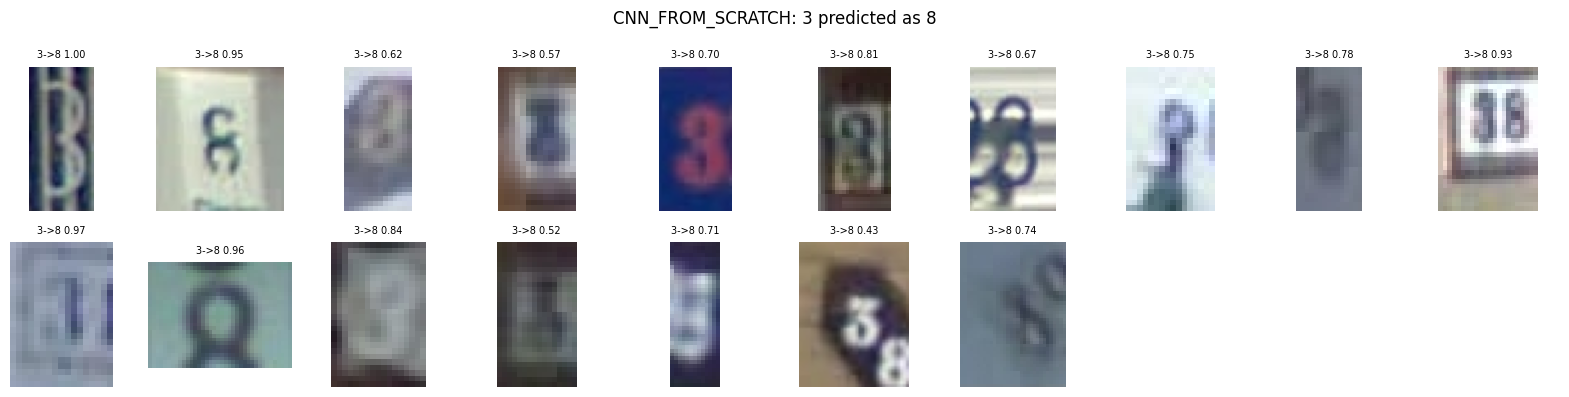

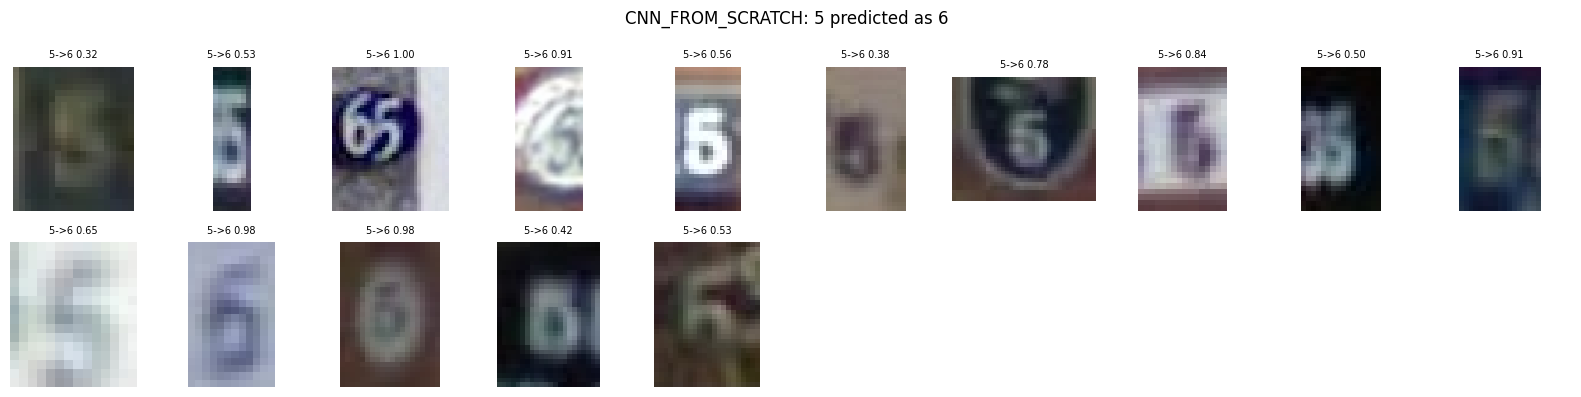

CNN_FROM_SCRATCH overall n= 25753 SVHN n= 25726 Printed n= 27 major confusions= [(53, 1, 4), (45, 1, 7), (41, 5, 3), (36, 2, 3), (36, 1, 3)]


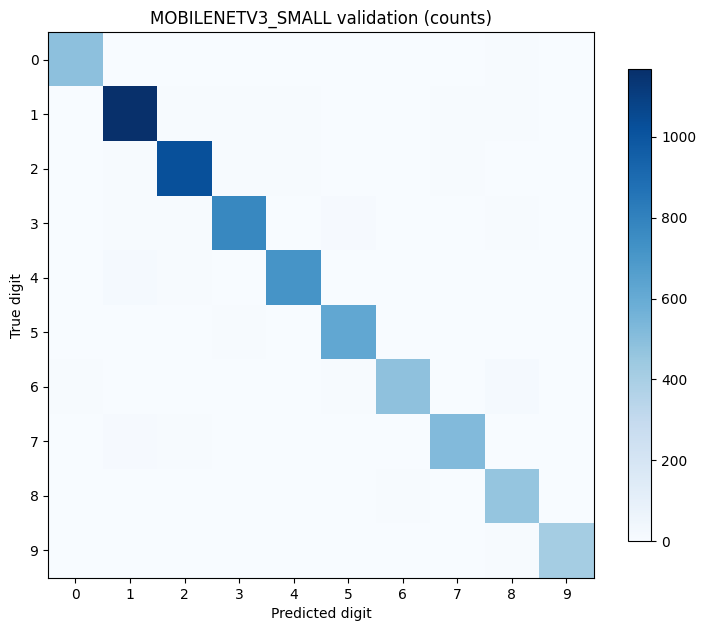

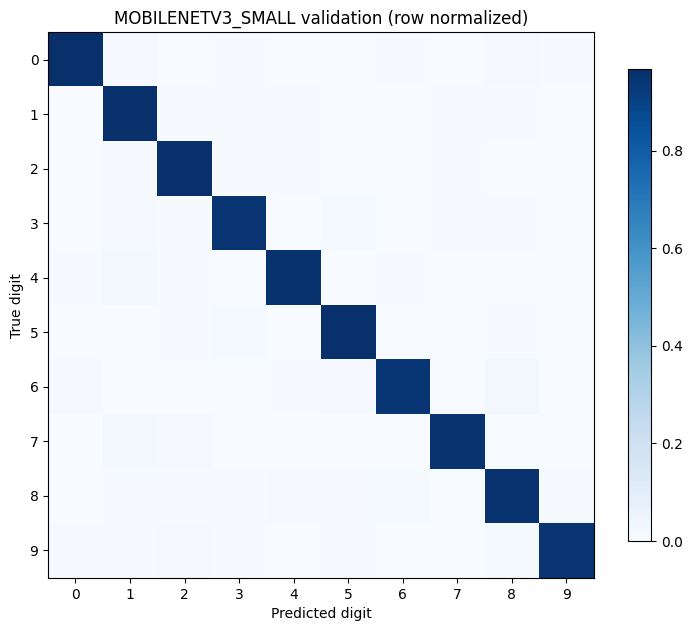

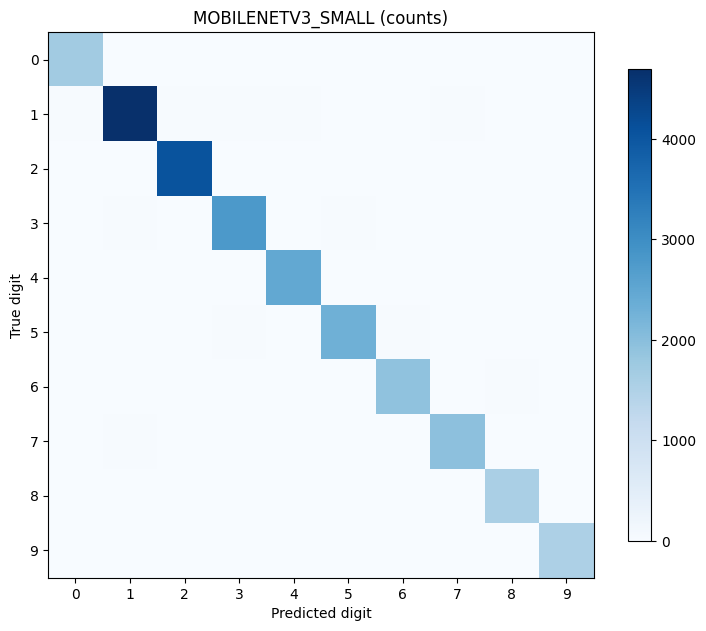

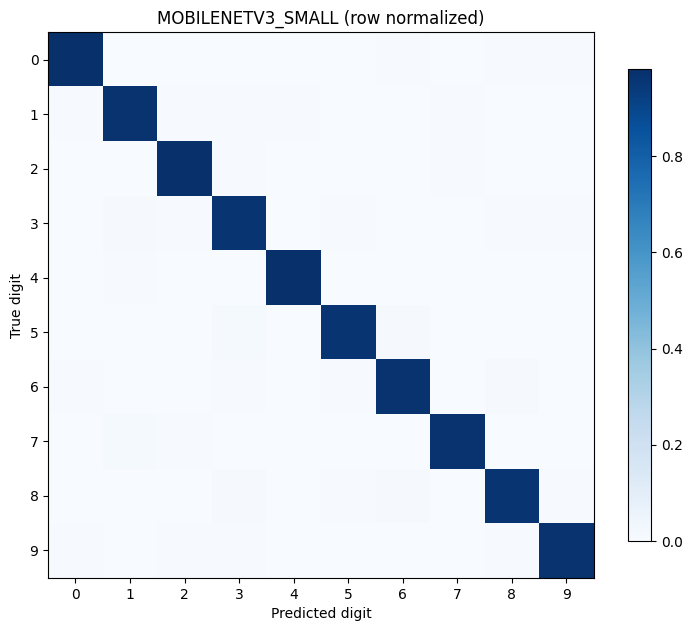

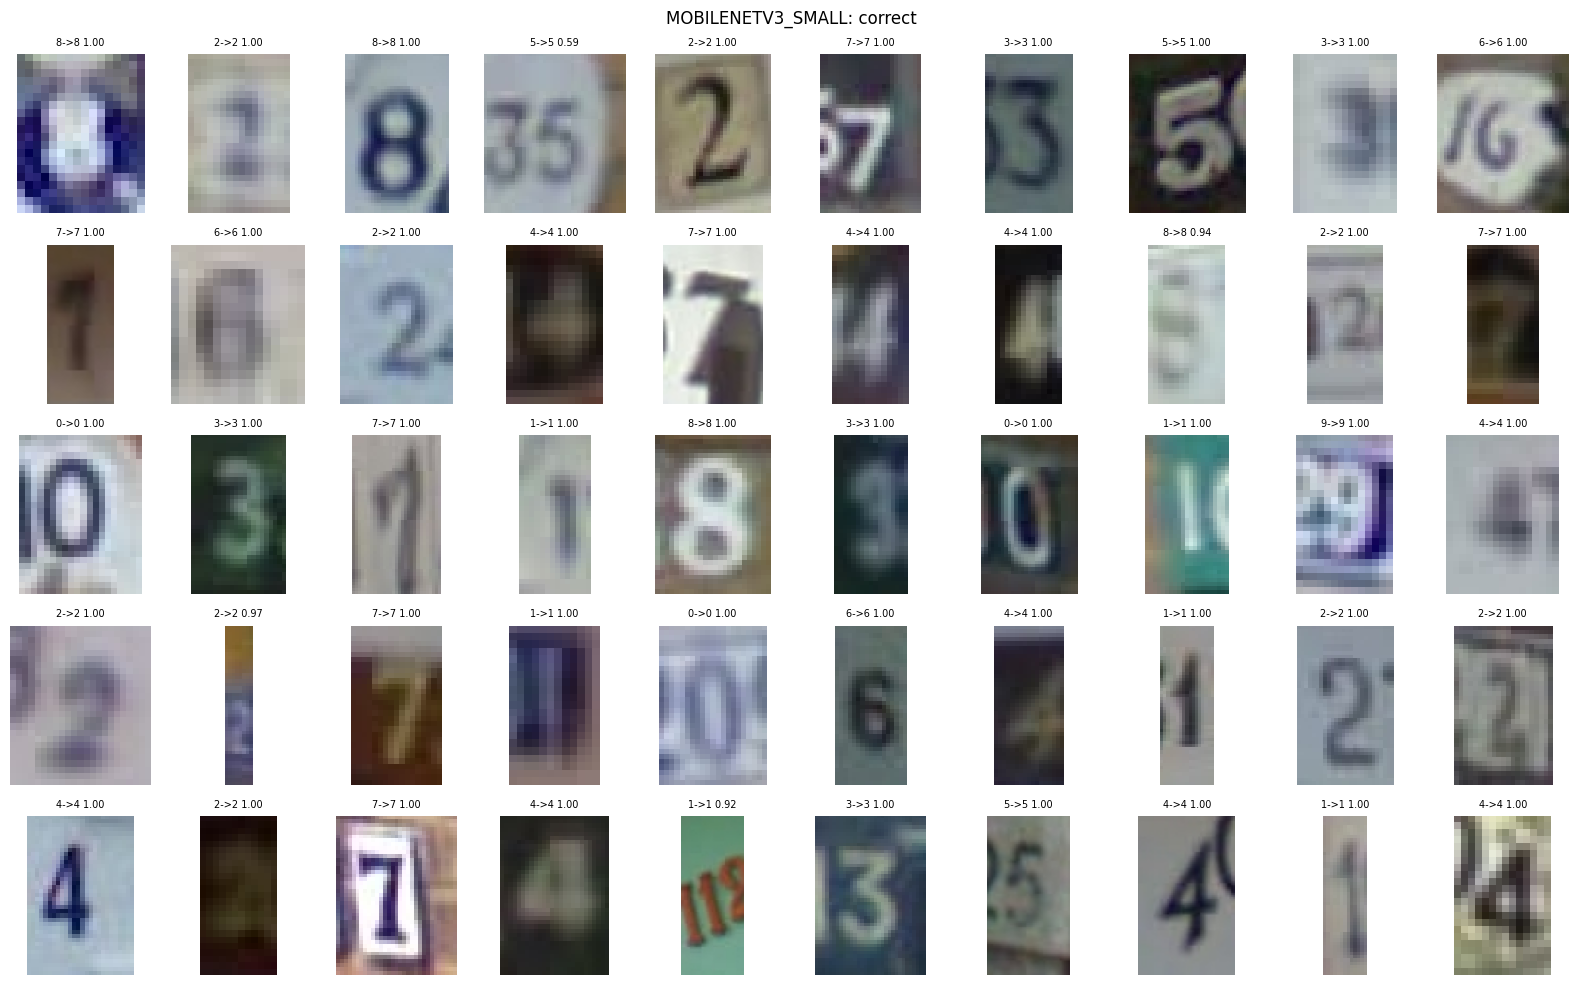

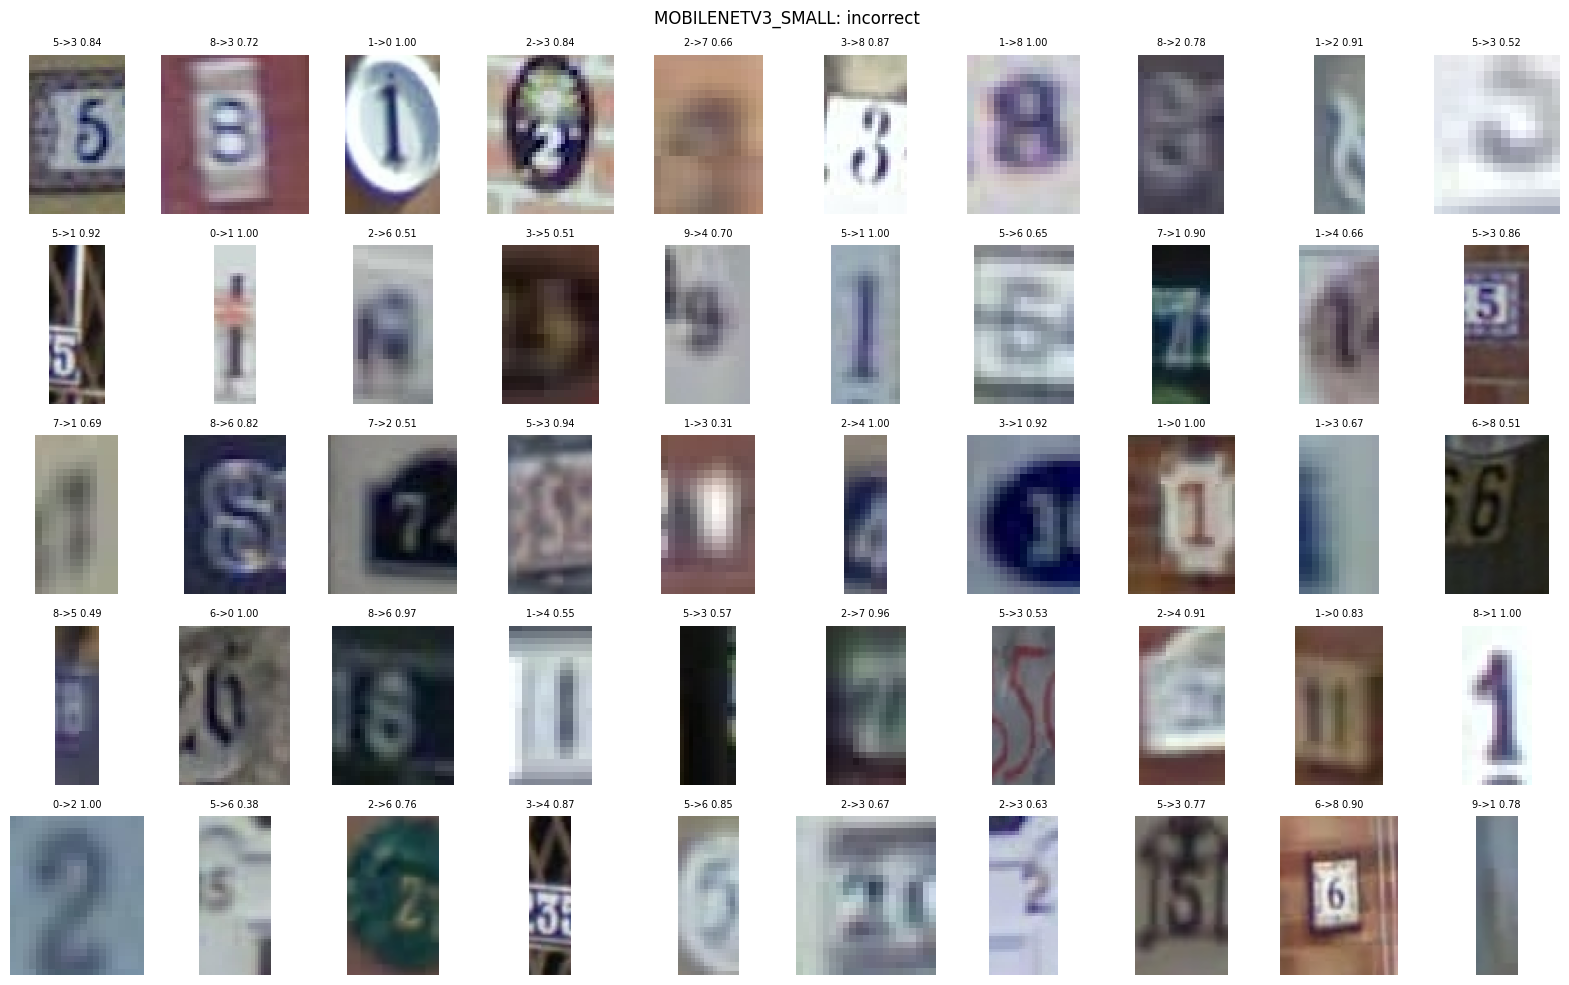

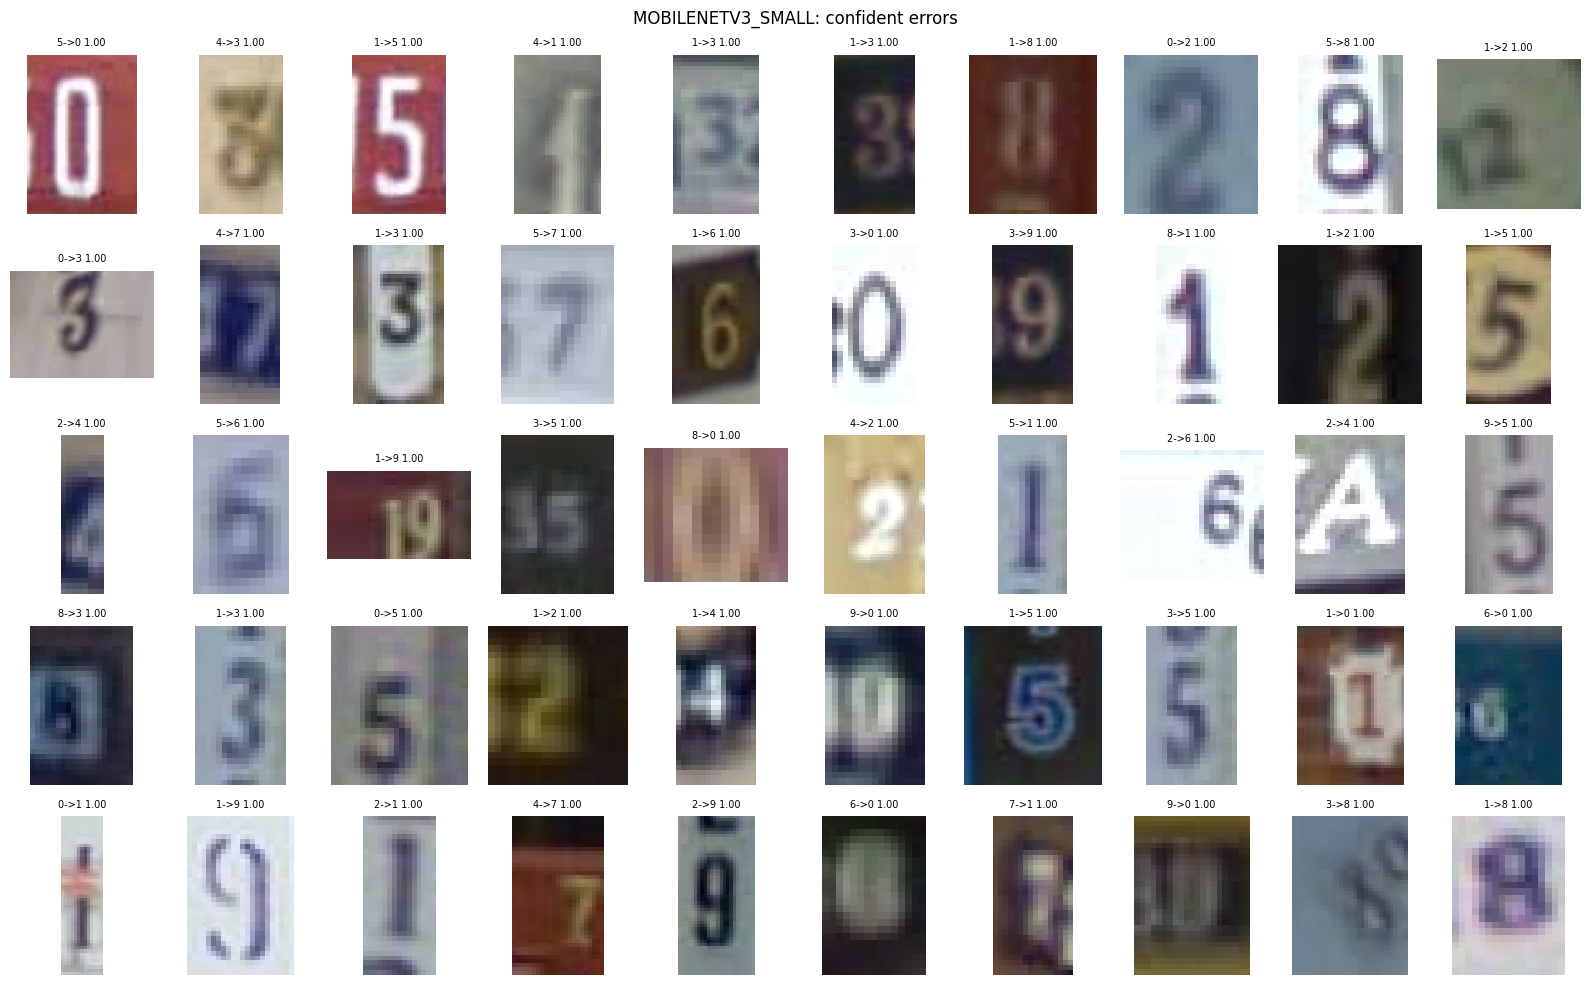

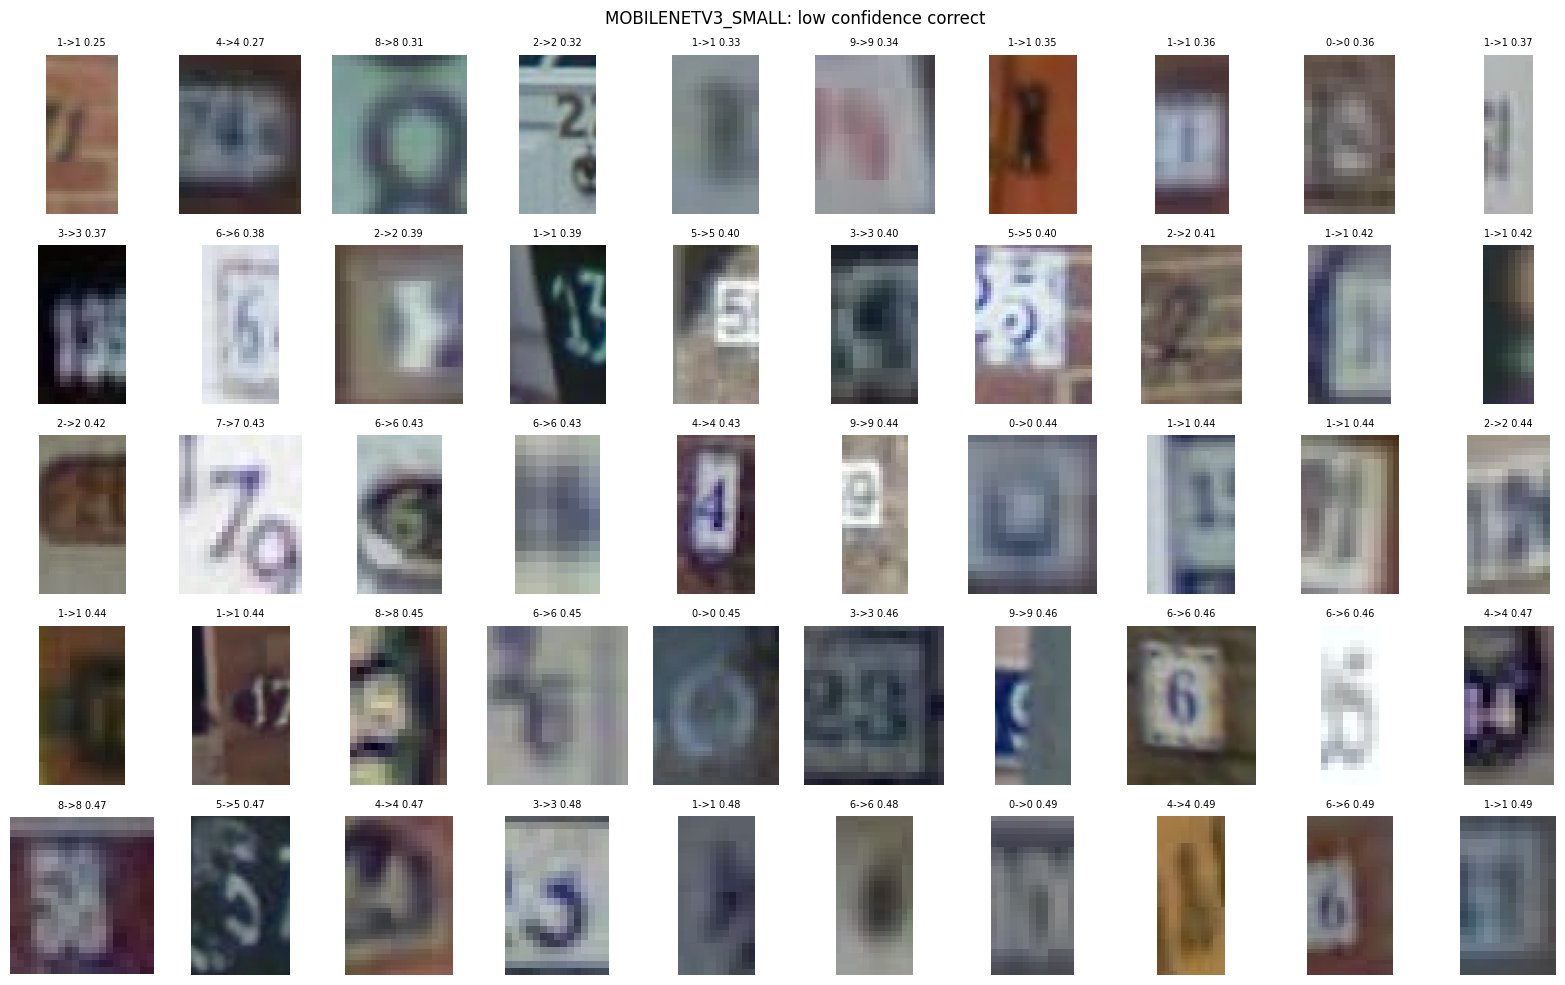

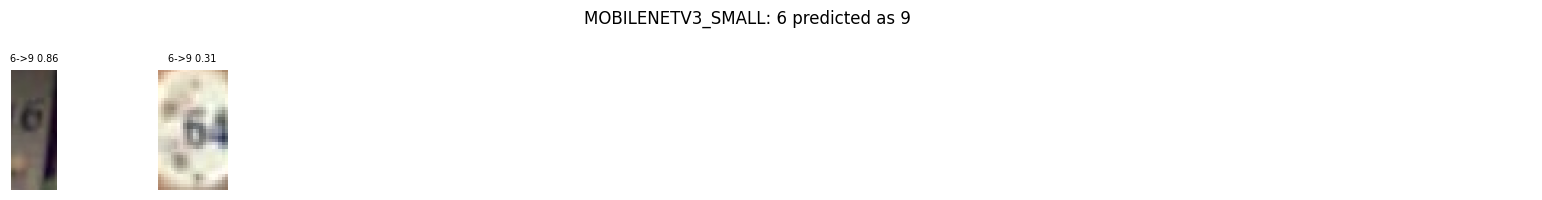

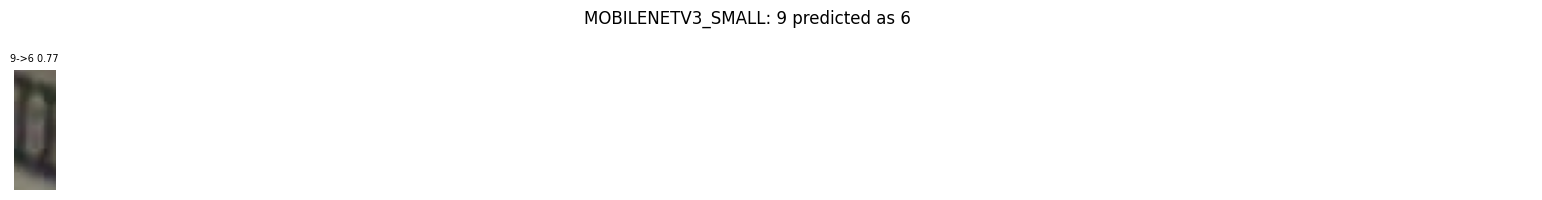

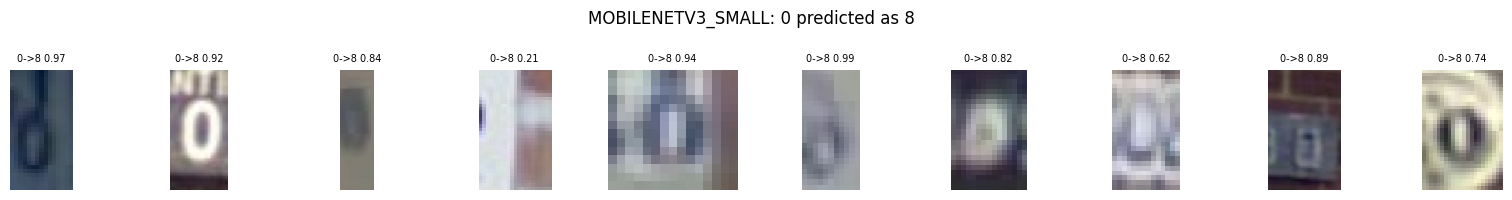

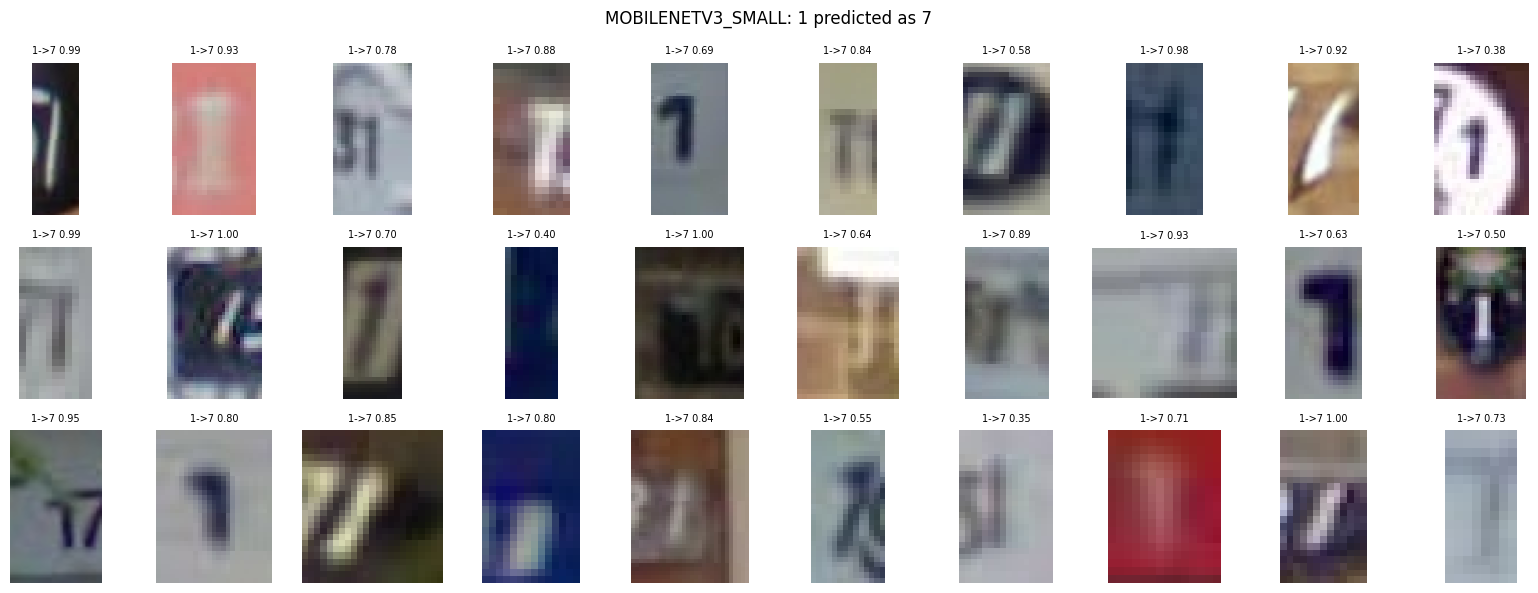

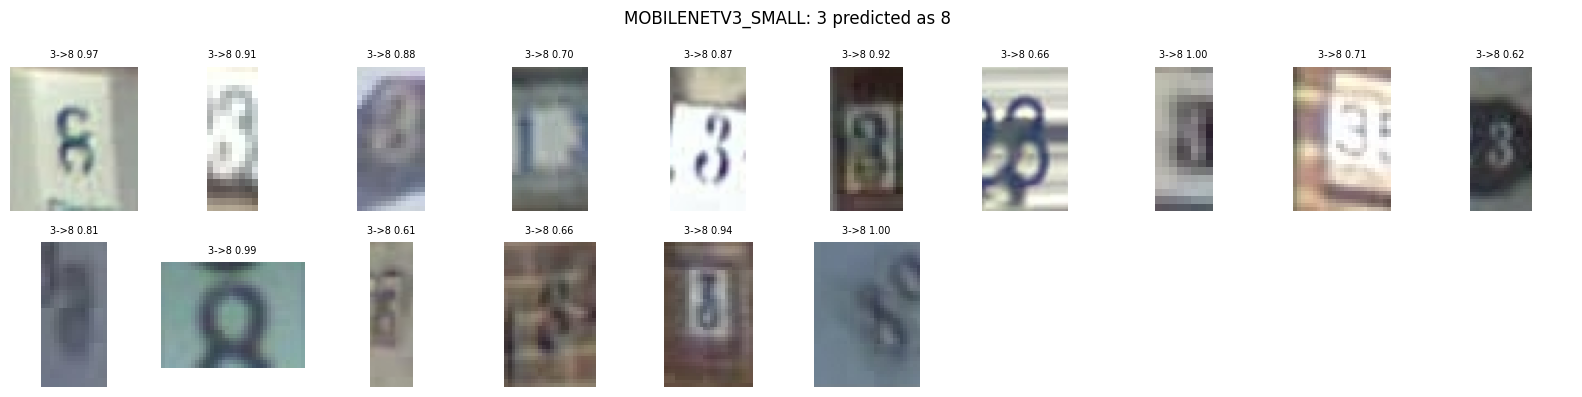

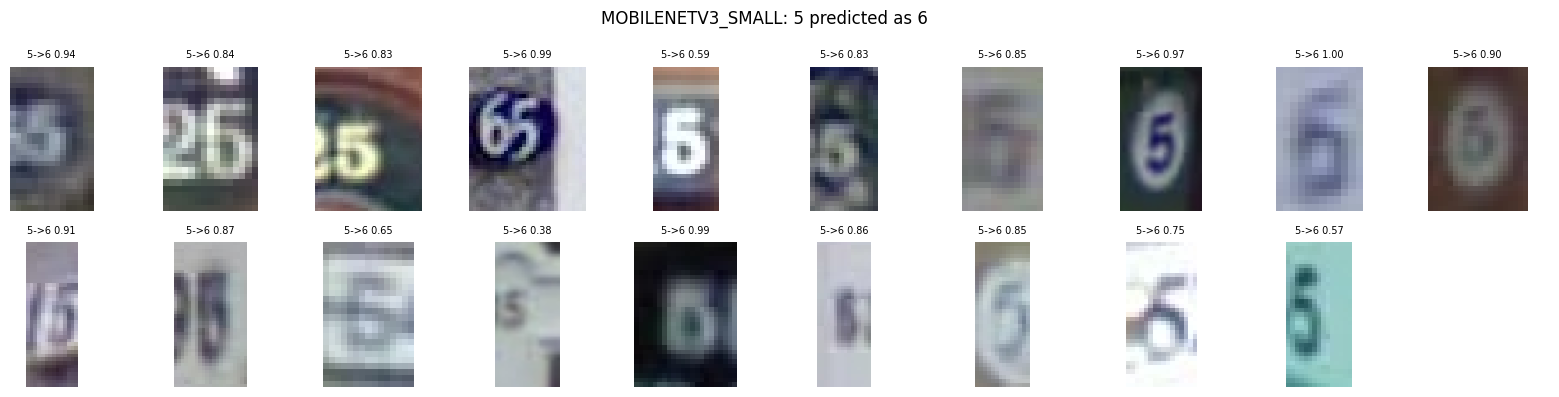

MOBILENETV3_SMALL overall n= 25753 SVHN n= 25726 Printed n= 27 major confusions= [(32, 5, 3), (30, 7, 1), (30, 1, 7), (29, 1, 4), (26, 1, 0)]


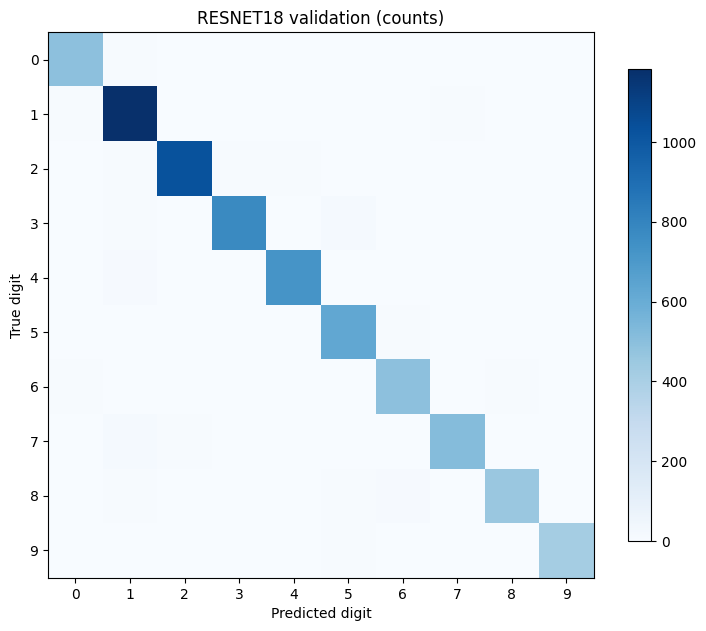

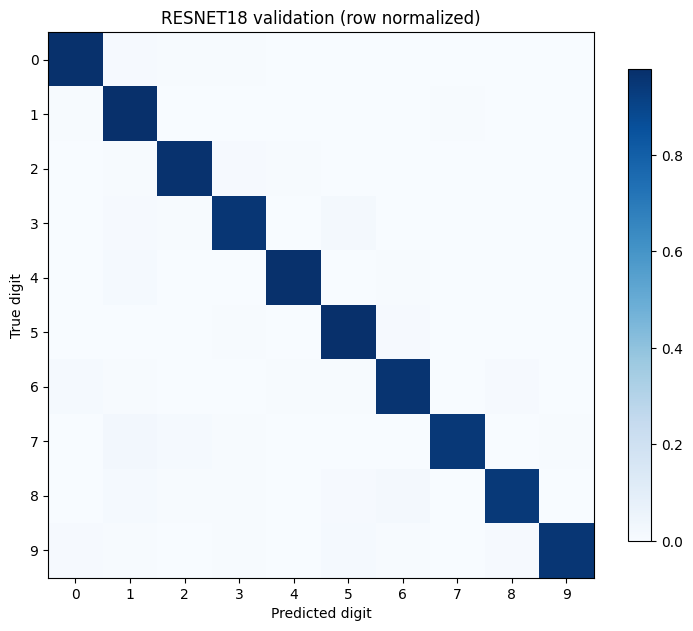

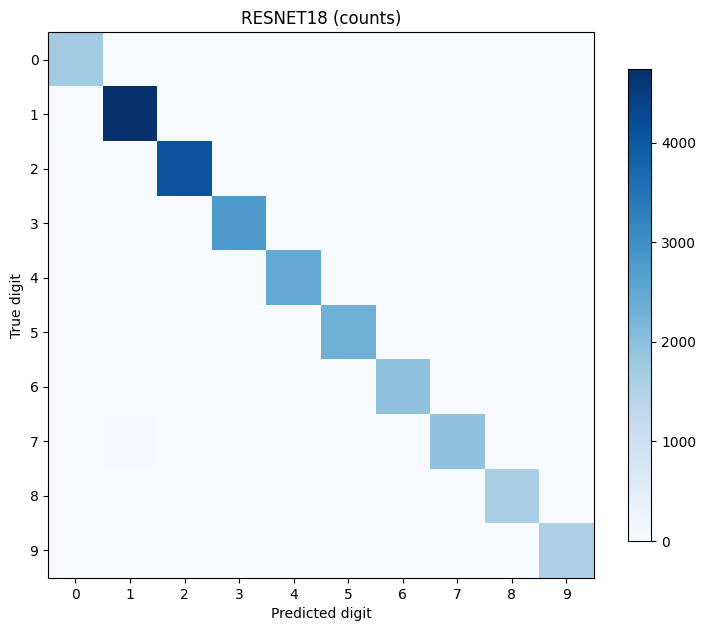

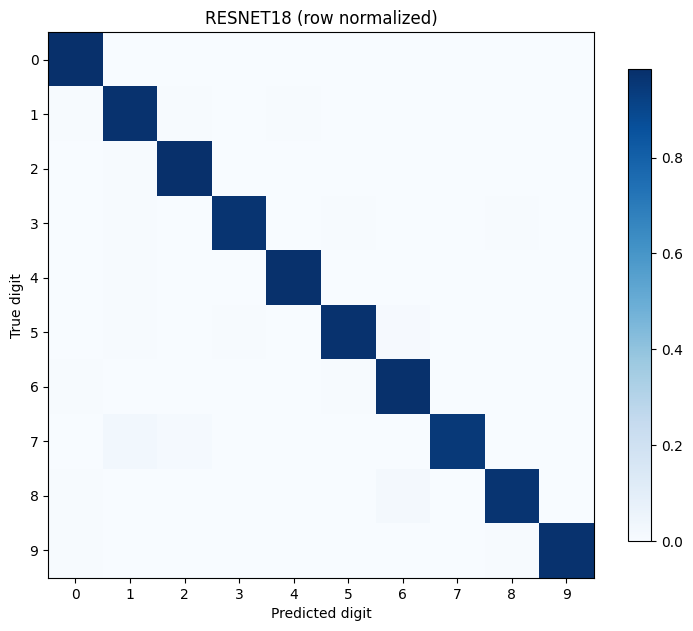

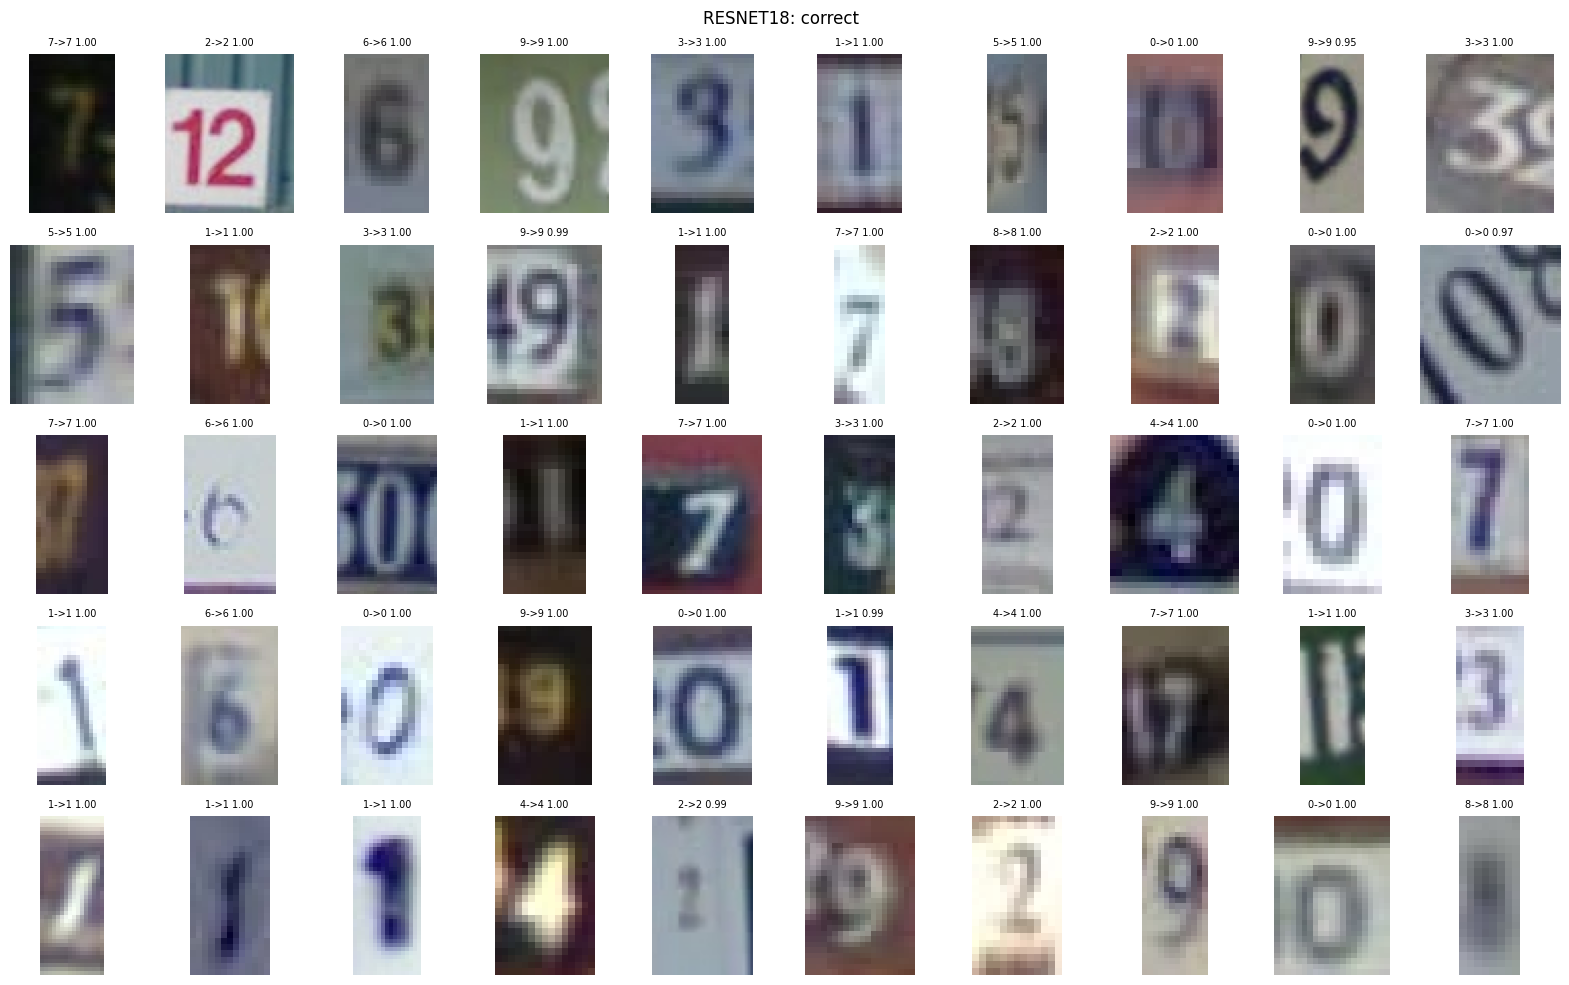

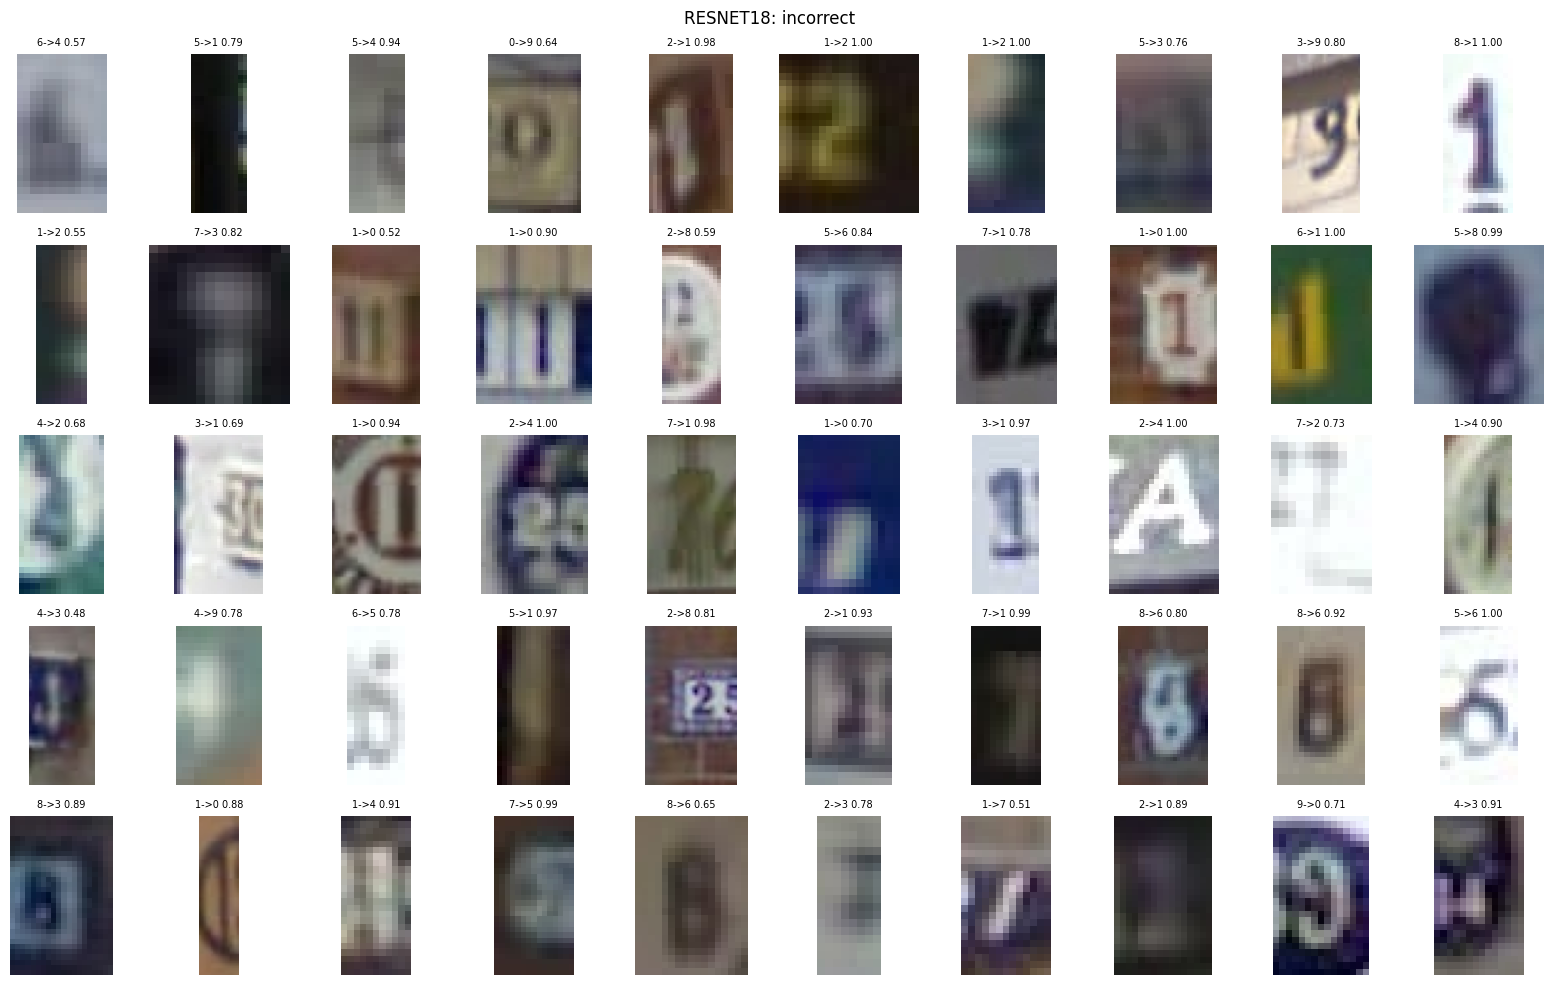

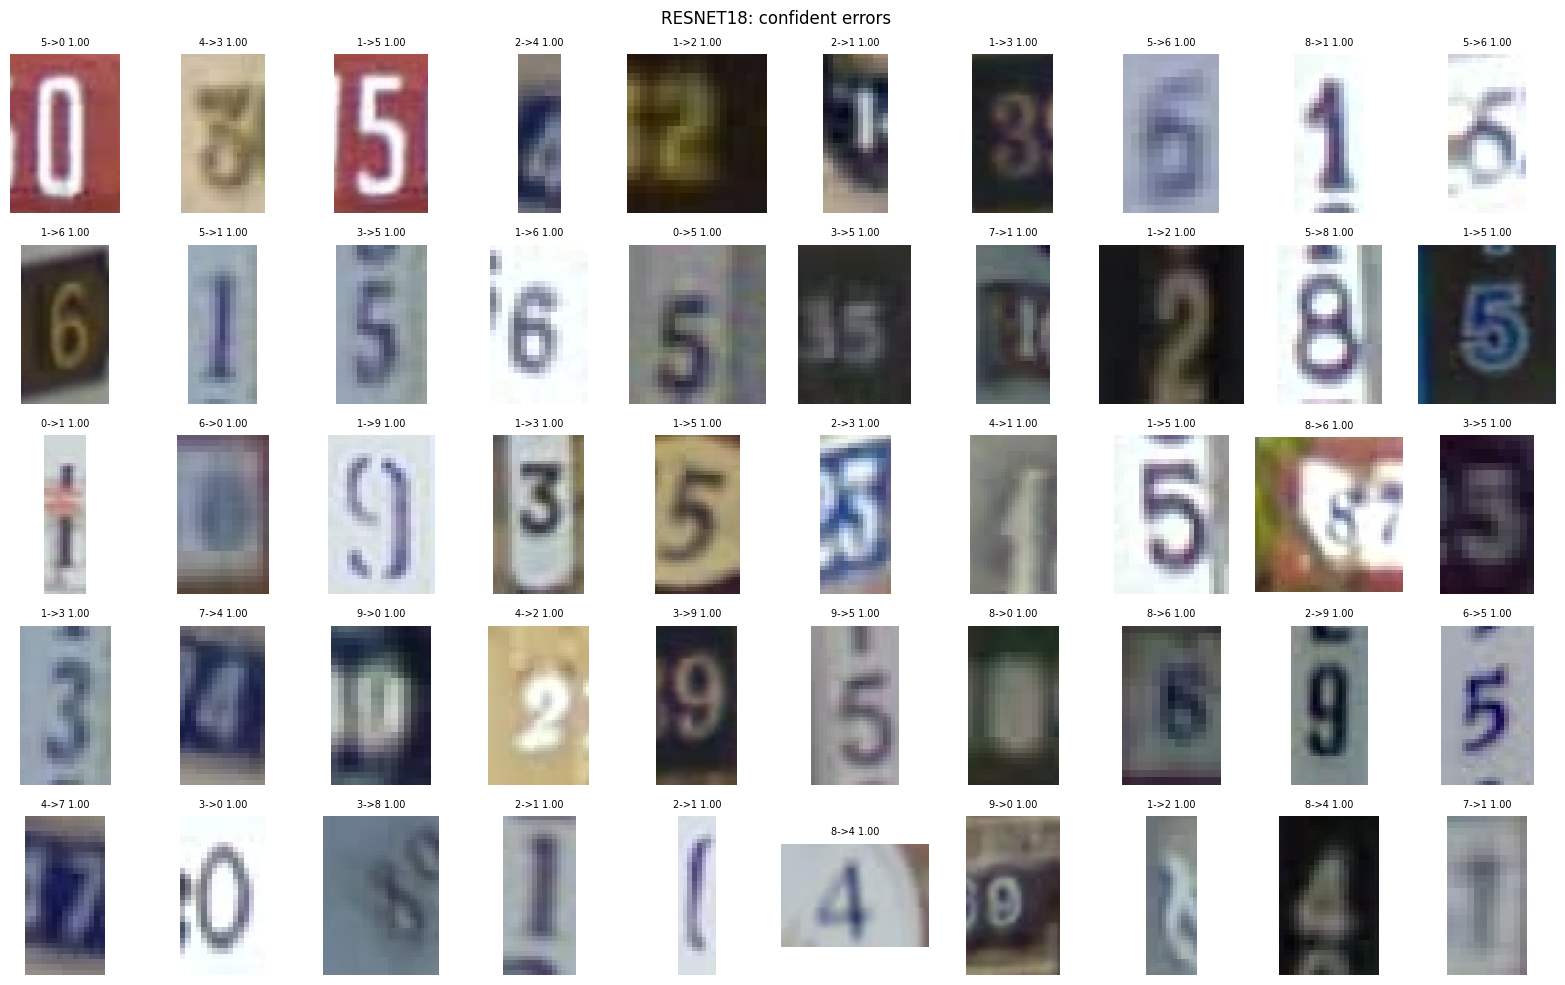

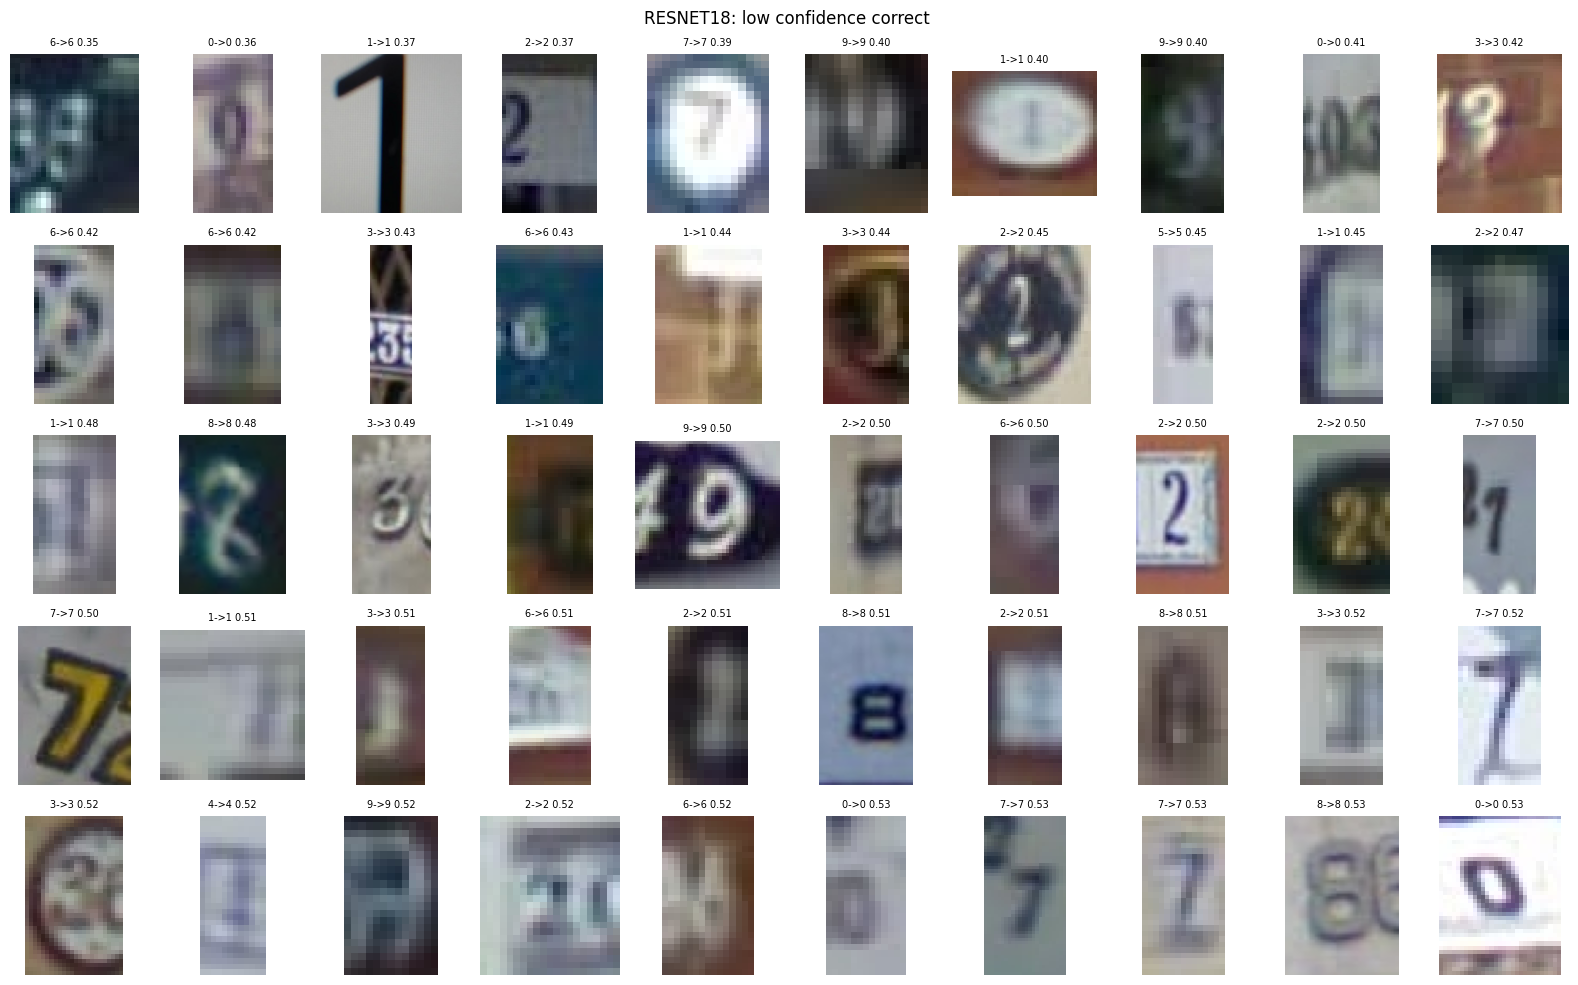

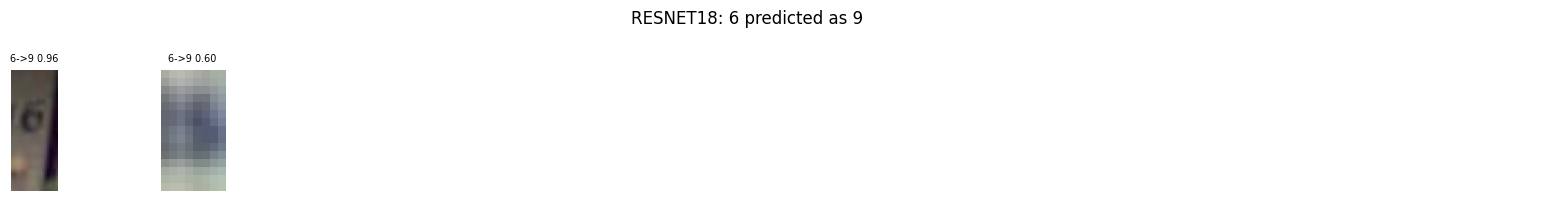

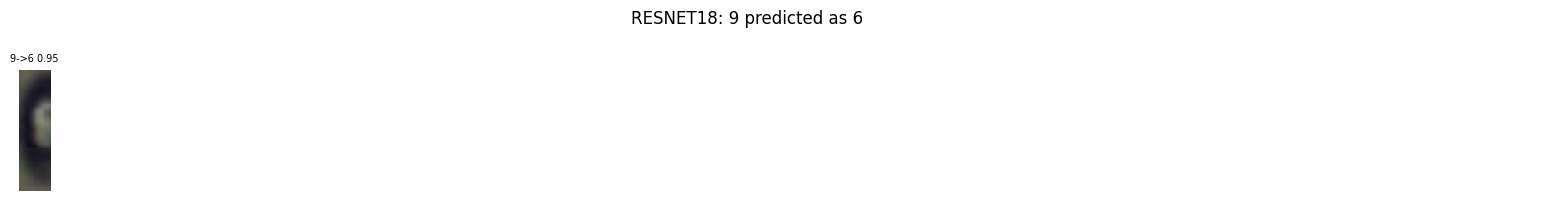

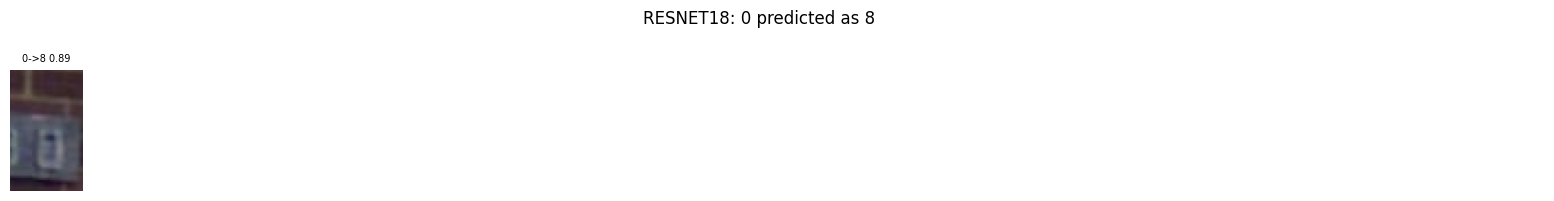

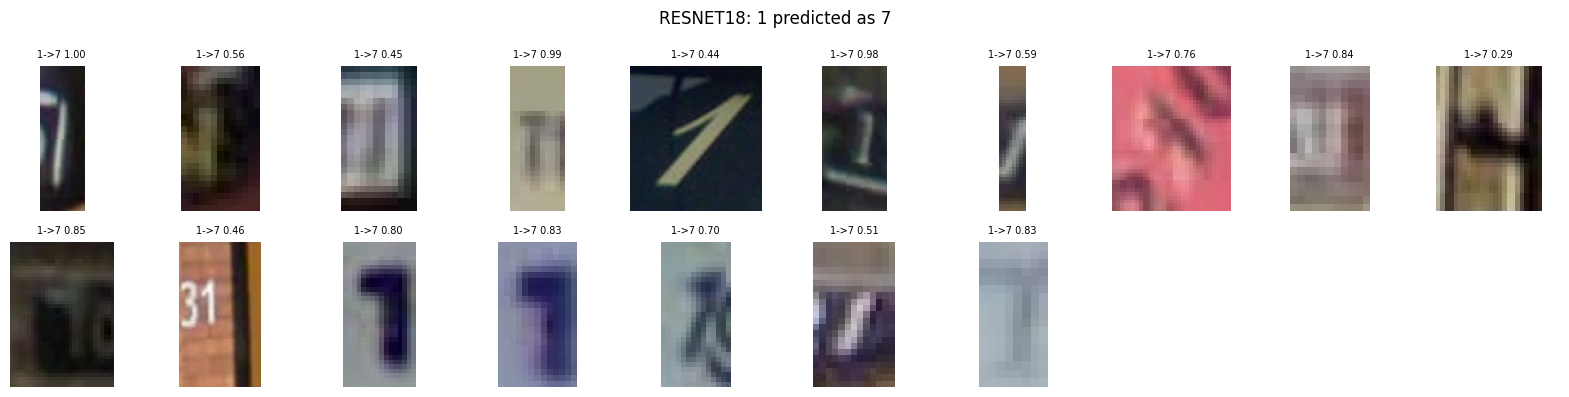

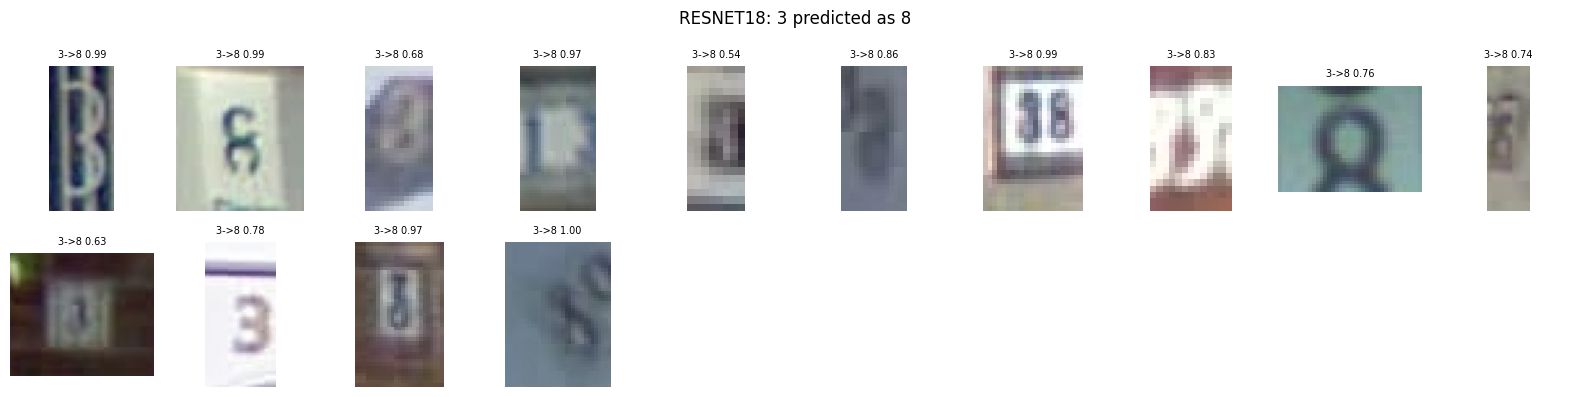

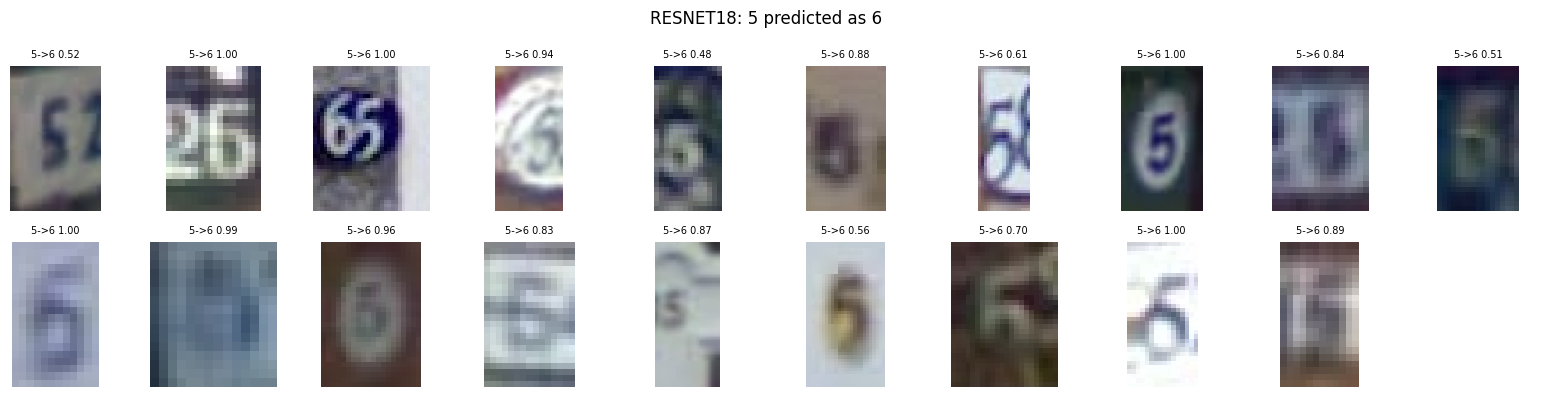

RESNET18 overall n= 25753 SVHN n= 25726 Printed n= 27 major confusions= [(58, 7, 1), (30, 8, 6), (30, 2, 1), (27, 7, 2), (23, 1, 4)]


In [9]:
if EVALUATE_TEST:
    assert not SMOKE_TEST
    all_models = {'CNN_FROM_SCRATCH', 'MOBILENETV3_SMALL', 'RESNET18'}
    for missing_name in all_models - set(trained):
        candidates = [Path(root) / missing_name.lower() / 'best.pt' for root in EXTERNAL_CHECKPOINT_ROOTS]
        existing = next((p for p in candidates if p.is_file()), None)
        if existing is None:
            raise FileNotFoundError(f'Missing full-run checkpoint for {missing_name}. Attach prior Kaggle output and set EXTERNAL_CHECKPOINT_ROOTS, or train all three here.')
        checkpoint = torch.load(existing, map_location='cpu', weights_only=False)
        assert checkpoint['model_name'] == missing_name and checkpoint['input_size'] == INPUT_SIZE
        assert not checkpoint['smoke_test'], 'A smoke checkpoint cannot enter the final comparison.'
        model, pretrained = create_model(missing_name, load_imagenet_weights=False)
        model.load_state_dict(checkpoint['state_dict'])
        model = model.to(device)
        output_dir = OUTPUT_ROOT / missing_name.lower()
        (output_dir / 'metrics').mkdir(parents=True, exist_ok=True)
        (output_dir / 'plots').mkdir(exist_ok=True)
        shutil.copy2(existing, output_dir / 'best.pt')
        prior_last = existing.with_name('last.pt')
        if prior_last.is_file():
            shutil.copy2(prior_last, output_dir / 'last.pt')
        _, val_loader, _ = loaders(pretrained)
        validation = run_epoch(model, val_loader, nn.CrossEntropyLoss(weight=class_weights))
        trained[missing_name] = {'model': model, 'pretrained': pretrained,
                                 'best_epoch': checkpoint['epoch'], 'validation': validation,
                                 'output_dir': output_dir}
        del val_loader
    assert set(trained) == all_models, 'All three full-run checkpoints are required before test.'
    assert all(not torch.load(result['output_dir'] / 'best.pt', map_location='cpu', weights_only=False)['smoke_test']
               for result in trained.values())

def predict_frame(model, loader):
    model.eval()
    records = []
    with torch.inference_mode():
        for images, labels, paths, sources in loader:
            logits = model(images.to(device, non_blocking=True))
            probabilities = logits.softmax(1).cpu()
            predicted = probabilities.argmax(1)
            confidence = probabilities.max(1).values
            for path, source, true, pred, conf in zip(paths, sources, labels.tolist(), predicted.tolist(), confidence.tolist()):
                records.append({'filename': path, 'source_dataset': source, 'true_class': true,
                                'predicted_class': pred, 'confidence': conf, 'correct': true == pred})
    return pd.DataFrame.from_records(records)

def metrics_row(frame, model_name, source):
    row = classification_metrics(frame['true_class'].to_numpy(), frame['predicted_class'].to_numpy())
    return {'Model': model_name, 'Source': source, **row}

def make_confusion(predictions, output_dir, title):
    matrix = confusion_matrix(predictions.true_class, predictions.predicted_class, labels=list(range(10)))
    for normalized in (False, True):
        values = matrix.astype(float)
        if normalized:
            values /= np.maximum(values.sum(axis=1, keepdims=True), 1)
        fig, ax = plt.subplots(figsize=(7.5, 6.5))
        image = ax.imshow(values, cmap='Blues')
        ax.set(xticks=range(10), yticks=range(10), xlabel='Predicted digit', ylabel='True digit',
               title=title + (' (row normalized)' if normalized else ' (counts)'))
        fig.colorbar(image, ax=ax, shrink=0.8)
        fig.tight_layout()
        fig.savefig(output_dir / ('confusion_normalized.png' if normalized else 'confusion_counts.png'), dpi=150)
        plt.show()
    return matrix

def prediction_gallery(frame, path, title):
    if frame.empty:
        return
    n = min(50, len(frame))
    fig, axes = plt.subplots(math.ceil(n / 10), 10, figsize=(16, 2 * math.ceil(n / 10)))
    for ax in np.asarray(axes).reshape(-1): ax.axis('off')
    for ax, (_, row) in zip(np.asarray(axes).reshape(-1), frame.head(n).iterrows()):
        with Image.open(DATA_ROOT / row.filename) as image: ax.imshow(image.convert('RGB'))
        ax.set_title(f"{row.true_class}->{row.predicted_class} {row.confidence:.2f}", fontsize=7)
        ax.axis('off')
    fig.suptitle(title); fig.tight_layout(); fig.savefig(path, dpi=120); plt.show()

overall_rows, svhn_rows, printed_rows, per_class_rows, comparison_rows = [], [], [], [], []
validation_source_rows, validation_key_rates = [], {}
if EVALUATE_TEST:
    for model_name, result in trained.items():
        _, val_loader, test_loader = loaders(result['pretrained'])
        val_predictions = predict_frame(result['model'], val_loader)
        for source in ('Overall', 'SVHN', 'Printed'):
            subset = val_predictions if source == 'Overall' else val_predictions.loc[val_predictions.source_dataset == source]
            validation_source_rows.append(metrics_row(subset, model_name, source))
        validation_plots = result['output_dir'] / 'plots' / 'validation'
        validation_plots.mkdir(parents=True, exist_ok=True)
        val_matrix = make_confusion(val_predictions, validation_plots, model_name + ' validation')
        key_pairs = [(0, 8), (1, 7), (3, 8), (5, 6), (6, 9), (9, 6)]
        validation_key_rates[model_name] = sum(int(val_matrix[a, b]) for a, b in key_pairs) / len(val_predictions)
        val_class_report = classification_report(val_predictions.true_class, val_predictions.predicted_class,
                                                 labels=list(range(10)), output_dict=True, zero_division=0)
        pd.DataFrame([{'Digit': digit, 'Precision': val_class_report[str(digit)]['precision'],
                       'Recall': val_class_report[str(digit)]['recall'],
                       'F1': val_class_report[str(digit)]['f1-score'],
                       'Class Accuracy': val_class_report[str(digit)]['recall'],
                       'Support': val_class_report[str(digit)]['support']} for digit in range(10)]).to_csv(
            result['output_dir'] / 'metrics' / 'validation_per_class.csv', index=False)
        predictions = predict_frame(result['model'], test_loader)
        output_dir = result['output_dir']
        metrics_dir = output_dir / 'metrics'
        plots_dir = output_dir / 'plots'
        predictions.to_csv(metrics_dir / 'test_predictions.csv', index=False)
        overall = metrics_row(predictions, model_name, 'Overall')
        svhn = metrics_row(predictions.loc[predictions.source_dataset == 'SVHN'], model_name, 'SVHN')
        printed = metrics_row(predictions.loc[predictions.source_dataset == 'Printed'], model_name, 'Printed')
        overall_rows.append(overall); svhn_rows.append(svhn); printed_rows.append(printed)
        for source, subset in [('Overall', predictions), ('SVHN', predictions.loc[predictions.source_dataset == 'SVHN']),
                               ('Printed', predictions.loc[predictions.source_dataset == 'Printed'])]:
            report = classification_report(subset.true_class, subset.predicted_class, labels=list(range(10)),
                                           output_dict=True, zero_division=0)
            for digit in range(10):
                item = report[str(digit)]
                per_class_rows.append({'Model': model_name, 'Source': source, 'Digit': digit,
                                       'Precision': item['precision'], 'Recall': item['recall'],
                                       'F1': item['f1-score'], 'Class Accuracy': item['recall'],
                                       'Support': item['support']})
        matrix = make_confusion(predictions, plots_dir, model_name)
        predictions['correct'] = predictions.true_class == predictions.predicted_class
        prediction_gallery(predictions.loc[predictions.correct].sample(frac=1, random_state=SEED),
                           plots_dir / 'correct_50.png', model_name + ': correct')
        prediction_gallery(predictions.loc[~predictions.correct].sample(frac=1, random_state=SEED),
                           plots_dir / 'incorrect_50.png', model_name + ': incorrect')
        prediction_gallery(predictions.loc[~predictions.correct].sort_values('confidence', ascending=False),
                           plots_dir / 'high_confidence_wrong.png', model_name + ': confident errors')
        prediction_gallery(predictions.loc[predictions.correct].sort_values('confidence'),
                           plots_dir / 'low_confidence_correct.png', model_name + ': low confidence correct')
        for true_digit, pred_digit in ((6, 9), (9, 6), (0, 8), (1, 7), (3, 8), (5, 6)):
            subset = predictions.loc[(predictions.true_class == true_digit) & (predictions.predicted_class == pred_digit)]
            prediction_gallery(subset, plots_dir / f'{true_digit}_as_{pred_digit}.png',
                               f'{model_name}: {true_digit} predicted as {pred_digit}')
        major_pairs = sorted([(int(matrix[i, j]), i, j) for i in range(10) for j in range(10) if i != j], reverse=True)[:5]
        (metrics_dir / 'major_confusions.json').write_text(json.dumps(major_pairs, indent=2))
        print(model_name, 'overall n=', overall['n'], 'SVHN n=', svhn['n'], 'Printed n=', printed['n'],
              'major confusions=', major_pairs)
        del val_loader, test_loader


## 6. Deployment-oriented latency and comparison

Latency measures an already-preprocessed 1×3×128×128 tensor, excluding camera capture, crop extraction, and YOLO26/ROS work. CPU and GPU numbers are specific to the Kaggle machine. CPU and GPU use the same warmup and 100 timed batch-1 inferences. A later robot-host benchmark is still required.


,Model,Pretraining,Parameters,Model Size MB,Best Epoch,Validation Accuracy,Validation Macro F1,Test Accuracy,Test Macro F1,SVHN Test Accuracy,SVHN Test N,Printed Test Accuracy,Printed Test N,Printed Val Accuracy,Printed Val N,Val Key Confusion Rate,CPU Latency ms,GPU Latency ms,Images/sec
0,CNN_FROM_SCRATCH,None,128762,0.5306,24,0.9459,0.9448,0.9616,0.9606,0.9617,25726,0.8889,27,0.7179,39,0.0027,5.4777,0.8286,1206.7880
1,MOBILENETV3_SMALL,ImageNet,1528106,6.2356,20,0.9583,0.9569,0.9705,0.9688,0.9705,25726,0.9630,27,0.8205,39,0.0033,7.8039,4.7921,208.6772
2,RESNET18,ImageNet,11181642,44.7991,19,0.9650,0.9637,0.9753,0.9746,0.9754,25726,0.9259,27,0.8718,39,0.0027,14.7933,2.2931,436.0894


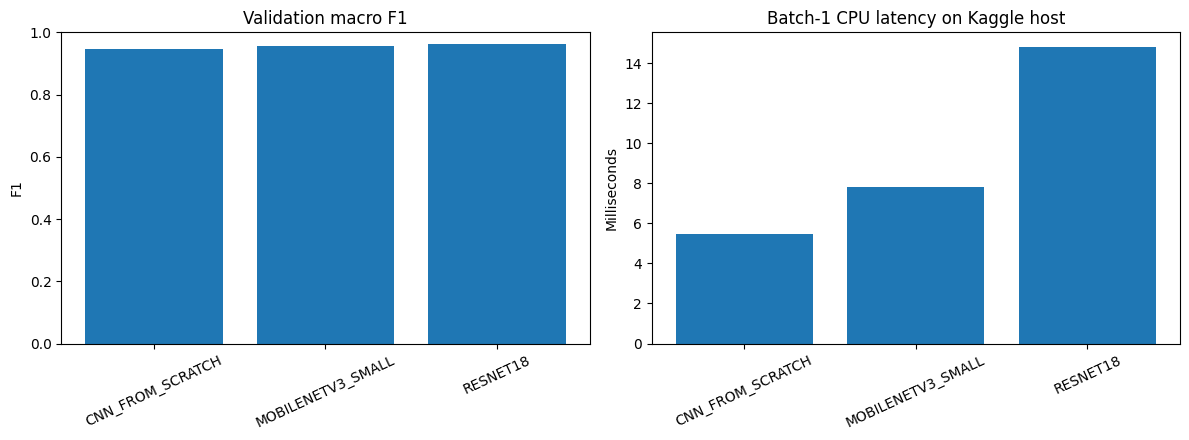

In [10]:
def latency_ms(model, target_device, repeats=100, warmup=20):
    candidate = copy.deepcopy(model).to(target_device).eval()
    sample = torch.zeros(1, 3, INPUT_SIZE, INPUT_SIZE, device=target_device)
    with torch.inference_mode():
        for _ in range(warmup): candidate(sample)
        if target_device.type == 'cuda': torch.cuda.synchronize()
        started = time.perf_counter()
        for _ in range(repeats): candidate(sample)
        if target_device.type == 'cuda': torch.cuda.synchronize()
    elapsed = (time.perf_counter() - started) * 1000 / repeats
    del candidate
    return elapsed

if EVALUATE_TEST:
    pd.DataFrame(overall_rows).to_csv(OUTPUT_ROOT / 'overall_metrics.csv', index=False)
    pd.DataFrame(svhn_rows).to_csv(OUTPUT_ROOT / 'svhn_metrics.csv', index=False)
    pd.DataFrame(printed_rows).to_csv(OUTPUT_ROOT / 'printed_metrics.csv', index=False)
    pd.DataFrame(per_class_rows).to_csv(OUTPUT_ROOT / 'per_class_metrics.csv', index=False)
    pd.DataFrame(validation_source_rows).to_csv(OUTPUT_ROOT / 'validation_source_metrics.csv', index=False)
    for name, result in trained.items():
        model = result['model']
        cpu_ms = latency_ms(model, torch.device('cpu'))
        gpu_ms = latency_ms(model, torch.device('cuda')) if device.type == 'cuda' else np.nan
        effective_ms = gpu_ms if device.type == 'cuda' else cpu_ms
        overall = next(row for row in overall_rows if row['Model'] == name)
        svhn = next(row for row in svhn_rows if row['Model'] == name)
        printed = next(row for row in printed_rows if row['Model'] == name)
        printed_val = next(row for row in validation_source_rows if row['Model'] == name and row['Source'] == 'Printed')
        comparison_rows.append({
            'Model': name, 'Pretraining': 'None' if name == 'CNN_FROM_SCRATCH' else 'ImageNet',
            'Parameters': sum(p.numel() for p in model.parameters()),
            'Model Size MB': (result['output_dir'] / 'best.pt').stat().st_size / 1e6,
            'Best Epoch': result['best_epoch'],
            'Validation Accuracy': result['validation']['accuracy'],
            'Validation Macro F1': result['validation']['macro_f1'],
            'Test Accuracy': overall['accuracy'], 'Test Macro F1': overall['macro_f1'],
            'SVHN Test Accuracy': svhn['accuracy'], 'SVHN Test N': svhn['n'],
            'Printed Test Accuracy': printed['accuracy'], 'Printed Test N': printed['n'],
            'Printed Val Accuracy': printed_val['accuracy'], 'Printed Val N': printed_val['n'],
            'Val Key Confusion Rate': validation_key_rates[name],
            'CPU Latency ms': cpu_ms, 'GPU Latency ms': gpu_ms, 'Images/sec': 1000 / effective_ms,
        })
    comparison = pd.DataFrame(comparison_rows)
    comparison.to_csv(OUTPUT_ROOT / 'model_comparison.csv', index=False)
    display(comparison.round(4))
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
    axes[0].bar(comparison['Model'], comparison['Validation Macro F1'])
    axes[0].set(title='Validation macro F1', ylabel='F1', ylim=(0, 1))
    axes[1].bar(comparison['Model'], comparison['CPU Latency ms'])
    axes[1].set(title='Batch-1 CPU latency on Kaggle host', ylabel='Milliseconds')
    for ax in axes: ax.tick_params(axis='x', rotation=25)
    fig.tight_layout(); fig.savefig(OUTPUT_ROOT / 'model_comparison.png', dpi=150); plt.show()
else:
    print('No test evaluation in this run. For the final comparison, use full-data checkpoints for all three models and set RUN_FINAL_EVALUATION=True.')


## 7. Final report and next phase

The candidate is provisional: among models within one percentage point of the best validation macro F1, rank CPU latency, Printed **validation** accuracy, and key validation confusion rate. Printed **test** accuracy is reported only after checkpoint selection and does not change the selection. The final deployed classifier requires actual white-paper digits on cube faces from the robot camera; this public-data stage is a **general digit model**.


In [11]:
if EVALUATE_TEST:
    best_validation = comparison['Validation Macro F1'].max()
    close = comparison.loc[comparison['Validation Macro F1'] >= best_validation - 0.01].copy()
    close['decision_score'] = (0.50 * close['CPU Latency ms'].rank(ascending=True) +
                               0.25 * close['Printed Val Accuracy'].rank(ascending=False) +
                               0.25 * close['Val Key Confusion Rate'].rank(ascending=True))
    provisional = close.sort_values('decision_score').iloc[0]['Model']
    lines = [
        '# Final digit model comparison',
        f'Dataset: {DATA_ROOT}; train/val/test = {len(metadata.loc[metadata.unified_split == "train"]):,}/'
        f'{len(val_frame):,}/{len(test_frame):,} crops.',
        f'Test sources: {test_frame.source_dataset.value_counts().to_dict()}. Printed test accuracy has a small denominator.',
        'All models use the same existing splits, input size, training augmentations, class weighting, and validation selection metric.',
        'The scratch CNN starts from random weights; MobileNetV3-Small and ResNet18 use official ImageNet weights.',
        f'Provisional candidate: **{provisional}**. Eligibility: validation macro F1 within 0.01 of best. '
        'Within that set: rank CPU latency (50%), Printed validation accuracy (25%), and key validation confusion rate (25%).',
        'Printed validation also has a small denominator; this ranking is a decision aid, not a statistical guarantee.',
        'Review model_comparison.csv, printed_metrics.csv, and each model’s major_confusions.json before committing to hardware.',
        'Kaggle batch-1 latency excludes camera capture, YOLO26, crop extraction, and ROS. Benchmark on the robot host next.',
        'Public-data performance does not establish accuracy on white-paper digits attached to cubes; collect real camera images and fine-tune later.',
        'Printed-domain adaptation is disabled in this baseline comparison.',
    ]
    for _, row in comparison.iterrows():
        confusion_file = OUTPUT_ROOT / row['Model'].lower() / 'metrics' / 'major_confusions.json'
        confusions = json.loads(confusion_file.read_text())
        lines.append(f"{row['Model']}: val macro F1={row['Validation Macro F1']:.4f}; test accuracy={row['Test Accuracy']:.4f}; "
                     f"Printed val accuracy={row['Printed Val Accuracy']:.4f} (n={int(row['Printed Val N'])}); "
                     f"Printed test accuracy={row['Printed Test Accuracy']:.4f} (n={int(row['Printed Test N'])}); "
                     f"CPU={row['CPU Latency ms']:.2f} ms; checkpoint={row['Model Size MB']:.2f} MB; "
                     f"major confusion counts={confusions}.")
    (OUTPUT_ROOT / 'final_model_report.md').write_text('\n\n'.join(lines) + '\n', encoding='utf-8')
    print((OUTPUT_ROOT / 'final_model_report.md').read_text())
else:
    print('Check losses and checkpoints. Complete all three full-data runs before the final evaluation.')
print('Artifacts:', OUTPUT_ROOT)


# Final digit model comparison

Dataset: /kaggle/input/datasets/aymenslimani/number-degit-dataset; train/val/test = 325,090/6,950/25,753 crops.

Test sources: {'SVHN': 25726, 'Printed': 27}. Printed test accuracy has a small denominator.

All models use the same existing splits, input size, training augmentations, class weighting, and validation selection metric.

The scratch CNN starts from random weights; MobileNetV3-Small and ResNet18 use official ImageNet weights.

Provisional candidate: **MOBILENETV3_SMALL**. Eligibility: validation macro F1 within 0.01 of best. Within that set: rank CPU latency (50%), Printed validation accuracy (25%), and key validation confusion rate (25%).

Printed validation also has a small denominator; this ranking is a decision aid, not a statistical guarantee.

Review model_comparison.csv, printed_metrics.csv, and each model’s major_confusions.json before committing to hardware.

Kaggle batch-1 latency excludes camera capture, YOLO26, crop extraction, and

### Optional later experiment: Printed Digit adaptation

Disabled by default. If explicitly enabled after the baseline comparison, this starts from the provisional full-data winner, uses every Printed train crop plus a seeded class-balanced SVHN train subset, and fine-tunes at a much lower learning rate. It writes to a separate directory and does not alter any baseline result.


In [12]:
if RUN_PRINTED_ADAPTATION:
    assert EVALUATE_TEST and not SMOKE_TEST, 'Complete the full baseline comparison first.'
    printed_train = metadata.loc[(metadata.unified_split == 'train') & (metadata.source_dataset == 'Printed')]
    svhn_train = metadata.loc[(metadata.unified_split == 'train') & (metadata.source_dataset == 'SVHN')]
    svhn_balanced = pd.concat([
        svhn_train.loc[svhn_train.digit == digit].sample(n=min(50, (svhn_train.digit == digit).sum()), random_state=SEED)
        for digit in range(10)
    ], ignore_index=True)
    adaptation_frame = pd.concat([printed_train, svhn_balanced], ignore_index=True)
    winner_info = trained[provisional]
    adapted = copy.deepcopy(winner_info['model']).to(device)
    adapted._head_only = False
    adaptation_loader = DataLoader(DigitCrops(adaptation_frame, make_transform(True, winner_info['pretrained'])),
                                   batch_size=min(BATCH_SIZE, 64), shuffle=True, num_workers=NUM_WORKERS,
                                   pin_memory=(device.type == 'cuda'), persistent_workers=(NUM_WORKERS > 0))
    _, adaptation_val_loader, adaptation_test_loader = loaders(winner_info['pretrained'])
    adaptation_optimizer = torch.optim.AdamW(adapted.parameters(), lr=2e-5, weight_decay=1e-4)
    adaptation_scaler = torch.amp.GradScaler('cuda', enabled=(device.type == 'cuda'))
    adaptation_criterion = nn.CrossEntropyLoss()
    adaptation_dir = OUTPUT_ROOT / 'printed_adaptation'
    adaptation_dir.mkdir(exist_ok=True)
    best_val_f1 = -1.0
    for adaptation_epoch in range(1, 4):
        run_epoch(adapted, adaptation_loader, adaptation_criterion, adaptation_optimizer, adaptation_scaler)
        val_result = run_epoch(adapted, adaptation_val_loader, adaptation_criterion)
        payload = {'state_dict': adapted.state_dict(), 'source_model': provisional,
                   'epoch': adaptation_epoch, 'validation_macro_f1': val_result['macro_f1']}
        torch.save(payload, adaptation_dir / 'last.pt')
        if val_result['macro_f1'] > best_val_f1:
            best_val_f1 = val_result['macro_f1']
            torch.save(payload, adaptation_dir / 'best.pt')
    adapted.load_state_dict(torch.load(adaptation_dir / 'best.pt', map_location='cpu', weights_only=False)['state_dict'])
    adapted_predictions = predict_frame(adapted, adaptation_test_loader)
    adapted_predictions.to_csv(adaptation_dir / 'test_predictions.csv', index=False)
    adaptation_results = pd.DataFrame([
        metrics_row(adapted_predictions, provisional + '_ADAPTED', 'Overall'),
        metrics_row(adapted_predictions.loc[adapted_predictions.source_dataset == 'SVHN'], provisional + '_ADAPTED', 'SVHN'),
        metrics_row(adapted_predictions.loc[adapted_predictions.source_dataset == 'Printed'], provisional + '_ADAPTED', 'Printed'),
    ])
    adaptation_results.to_csv(adaptation_dir / 'source_metrics.csv', index=False)
    display(adaptation_results)
else:
    print('Printed adaptation remains disabled; baseline results are isolated.')


Printed adaptation remains disabled; baseline results are isolated.
